In [3]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io import shapereader

import copy
import glob
import json

from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
import matplotlib

import numpy as np
import pandas as pd
import os
import re
import requests
import seaborn as sns
import time
import urllib.request


 
colors=['#332288','#88CCEE','#44AA99','#117733','#999933','#DDCC77','#CC6677','#882255','#AA4499']

matplotlib.rc('text', usetex=False)

fs = 13

matplotlib.rc('xtick', labelsize=fs)
matplotlib.rc('ytick', labelsize=fs)
matplotlib.rc('axes', labelsize=15)
plt.rcParams['axes.titley'] = 1.1




/exec/jlavoie/.conda/envs/cmip-data-usage/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [4]:
def twinbarplot(
    left,
    right,
    xticks,
    xlabel,
    ylabelL='Total Size of downloads (GB)',
    ylabelR='Number of Downloads',
    colorL=colors[0],
    colorR=colors[3],
    ax=None,
    log=True,
):
    # Define bar width
    bar_width = 0.4
    # Define the positions of the bars
    x = np.arange(len(xticks))
    
    if ax is None:
        # Create the figure and axis
        fig, ax1 = plt.subplots(figsize=(12, 6))
    else:
        fig, ax1=ax

    # Plot bars for "Number of Downloads"
    bars1 = ax1.bar(x - bar_width/2, left, bar_width, color=colorL)
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel(ylabelL, color=colorL)
    if log:
        ax1.set_yscale('log')
    ax1.tick_params(axis='y', labelcolor=colorL, which='both')
    ax1.set_xticks(x)
    ax1.set_xticklabels(xticks, rotation=30, ha='right')
    

    # Create a secondary y-axis
    ax2 = ax1.twinx()
    bars2 = ax2.bar(x + bar_width/2, right, bar_width,  color=colorR)
    ax2.set_ylabel(ylabelR, color=colorR)
    ax2.tick_params(axis='y', labelcolor=colorR, which='both')
    if log:
        ax2.set_yscale('log')
    return fig, ax1, ax2



# Section 3.1. Variable

## load and clean data

In [19]:
# load and clean df
df_raw= pd.read_csv(f"data/ESGF/cmip6-variables_13_01_2025.csv")
df= pd.read_csv(f"data/ESGF/cmip6-variables_13_01_2025.csv")
print('before')
print(str(df['number_of_downloads'].sum()),' files. ', str(df['total_size_GB'].sum()), ' GB.', len(df), 'lines' )

#var_table is unique
df['unique']=df['variable_code']+'_'+df['mip_table']

# check unique againts CV
allowed_unique=[]
with open(f"data/CVs/CMIP6_table_id.json") as f:
    d = json.load(f)
    allowed_tables=d["table_id"]
for table in allowed_tables:
    with open(f"data/CVs/Tables/CMIP6_{table}.json") as f:
        d = json.load(f)
        allowed_var=d['variable_entry'].keys()
        for var in allowed_var:
            allowed_unique.append(f"{var.lower()}_{table}")

df=df[df.unique.isin(allowed_unique)]
print('remove unique not in CVs')
print(str(df['number_of_downloads'].sum()),' files. ', str(df['total_size_GB'].sum()), ' GB.' , len(df), 'lines')


# get the simple frequency and delete row if table and time_frequency don't match
df['freqtab']= df['time_frequency']+'_'+df['mip_table']
freqtab=np.sort(list((df['freqtab'].unique())))
freqs=['dec','yr','mon','day','6hr','3hr','1hr','subhrPt','fx']
mapping={f:[v for v in freqs if v in f]for f in freqtab}
# if there are 2 freqs in freqtab, this means there is an issue. eg. day in Amon. delete the row
mapping={k:v[0] if len(v)==1 else 'error' for k,v in mapping.items()}
df['freq'] = df['freqtab'].map(mapping)
df=df[df['freq']!='error']
print('remove freq error')
print(str(df['number_of_downloads'].sum()),' files. ', str(df['total_size_GB'].sum()), ' GB.', len(df), 'lines' )



# #the repeats of unique are mistake, add them together.
# df=df.groupby('unique', as_index=False).agg({'variable_code': 'first', 'variable_long_name': 'first', 'mip_table': 'first',
#                          'total_size_GB': 'sum','number_of_downloads':'sum',  'freq':'first'})

# print('combine not unique')
# print(str(df['number_of_downloads'].sum()),' files. ', str(df['total_size_GB'].sum()), ' GB.', len(df), 'lines' )

df

before
236732332.0  files.  41731172.36000001  GB. 2213 lines
remove unique not in CVs
235950854.0  files.  40662659.67999999  GB. 2109 lines
remove freq error
235949502.0  files.  40662624.059999995  GB. 2101 lines


,variable_code,variable_long_name,time_frequency,mip_table,total_size_GB,number_of_downloads,unique,freqtab,freq
0,thetao,Sea Water Potential Temperature,mon,Omon,1811359.27,2352600.0,thetao_Omon,mon_Omon,mon
1,ua,Eastward Wind,mon,Amon,1806876.41,28026138.0,ua_Amon,mon_Amon,mon
2,ua,Eastward Wind,6hrPt,6hrLev,1598771.52,177363.0,ua_6hrLev,6hrPt_6hrLev,6hr
3,va,Northward Wind,6hrPt,6hrLev,1588914.67,172614.0,va_6hrLev,6hrPt_6hrLev,6hr
4,hus,Specific Humidity,6hrPt,6hrLev,1413408.35,168099.0,hus_6hrLev,6hrPt_6hrLev,6hr
...,...,...,...,...,...,...,...,...,...
2203,iareagr,Area Covered by Grounded Ice Sheet,yr,IyrGre,0.00,26.0,iareagr_IyrGre,yr_IyrGre,yr
2204,iareafl,Area Covered by Floating Ice Shelves,yr,IyrGre,0.00,23.0,iareafl_IyrGre,yr_IyrGre,yr
2205,ch4globalclim,Global Mean Mole Fraction of CH4,mon,Amon,0.00,1.0,ch4globalclim_Amon,mon_Amon,mon
2208,yvelsurf,Y-Component of Land Ice Surface Velocity,yr,IyrGre,0.00,2.0,yvelsurf_IyrGre,yr_IyrGre,yr


In [54]:
mask = (
    df
    .groupby("variable_code")["variable_long_name"]
    .transform("nunique") > 1
)

pd.set_option('display.max_rows', 1000)

df[mask].sort_values('variable_code')[["variable_code","variable_long_name"]]

,variable_code,variable_long_name
2148,aerssabnd,TOA Outgoing Shortwave Radiation
1439,aerssabnd,Aerosol Level Single Scattering Albedo for Eac...
1701,cct,OH Volume Mixing Ratio
840,cct,Air Pressure at Convective Cloud Top
1448,cct,Air Pressure at Convective Cloud Top
718,cct,Air Pressure at Convective Cloud Top
1850,cct,Air Pressure at Convective Cloud Top
1957,ch4global,Global Mean Mole Fraction of CH4
2197,ch4global,Air Pressure at Convective Cloud Base
2160,ch4global,Global Mean Mole Fraction of CH4


In [4]:
# create upload stats
if not os.path.exists("data/FreshEyes/upload_stats_only_stats_nodes.csv"):
    with open(f"data/CVs/CMIP6_table_id.json") as f:
        d = json.load(f)
        allowed_tables=d["table_id"]
    
    d_u={'mip_table':[],'variable_code':[],'upload_size_GB':[],'number_of_uploads':[]}
    for table in allowed_tables:
        print(table)
        with open(f"data/CVs/Tables/CMIP6_{table}.json") as f:
            d = json.load(f)
            allowed_var=d['variable_entry'].keys()
            for var in allowed_var:
                # only include data node that are included in cmcc dashboard
                with urllib.request.urlopen(f"https://esgf-data.dkrz.de/esg-search/search/"\
                                            f"?limit=0&format=application%2Fsolr%2Bjson&mip_era=CMIP6&"\
                                            "data_node=aims3.llnl.gov&data_node=data.meteo.unican.es&data_node=esg1.umr-cnrm.fr&data_node=esg-dn1.nsc.liu.se&data_node=esg-dn2.nsc.liu.se&data_node=esg-dn3.nsc.liu.se&data_node=esgf1.dkrz.de&data_node=esgf3.dkrz.de&data_node=esgf.bsc.es&data_node=esgf-data1.llnl.gov&data_node=esgf-data2.llnl.gov&data_node=esgf-data3.ceda.ac.uk&data_node=esgf-data3.llnl.gov&data_node=esgf-data4.lnll.gov&data_node=esgf-data7.ceda.ac.uk&data_node=esgf-data.ucar.edu&data_node=esgf.nci.org.au&data_node=esgf-node2.cmcc.it&data_node=vesg.ipsl.upmc.fr&"\
                                            f"variable_id={var}&table_id={table}&facets=size,number_of_files&distrib=true") as url:
                    data = json.load(url)
                    # number of datasets (ususally 1) * binary byte convert to decimal GB
                    l_size=[num*int(x)/1024**3 for x, num in zip(data['facet_counts']['facet_fields']['size'][::2],
                                                             data['facet_counts']['facet_fields']['size'][1::2])]
                    d_u['upload_size_GB'].append(np.sum(l_size))
                    # count number of files
                    l_num=[num*int(x) for x, num in zip(data['facet_counts']['facet_fields']['number_of_files'][::2],
                                                             data['facet_counts']['facet_fields']['number_of_files'][1::2])]
                    d_u['number_of_uploads'].append(np.sum(l_num))
                    d_u['mip_table'].append(table)
                    d_u['variable_code'].append(var)
    df_upload=pd.DataFrame(data=d_u)
    df_upload['variable_code']=df_upload['variable_code'].str.lower()
    df_upload['unique']=df_upload['variable_code']+'_'+df_upload['mip_table']
    display(df_upload)
    
    df_upload.to_csv(f"data/FreshEyes/upload_stats_only_stats_nodes.csv")

In [5]:
# add more info to df

# add dimensions
dimension=[]
for index, row in df.iterrows():
    table=row['mip_table']
    var=row['variable_code']
    with open(f"data/CVs/Tables/CMIP6_{table}.json") as f:
        d = json.load(f)
        entries=d['variable_entry']
        entries={k.lower():v for k,v in entries.items()} # CMCC data is all lowercase
        list_dim=entries[var]['dimensions'].split(' ')
        if 'latitude' in list_dim and 'longitude' in list_dim:
            cur_d='2'
            if len([l for l in list_dim if 'lev' in l])==1:
                cur_d='3'
        else:
            cur_d='?'
        dimension.append(cur_d)
df['dimension']=dimension

# add realm
def get_realm(table):
    with open(f"data/CVs/Tables/CMIP6_{table}.json") as f:
        d = json.load(f)
        return(d['Header']['realm'])
df['realm']=df['mip_table'].apply(lambda x: get_realm(x))

#pangeo
df_google = pd.read_csv('https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv')
df_google['unique']= df_google['variable_id'].str.lower()+'_'+df_google['table_id']
df['google']=df['unique'].isin(df_google['unique'])

df_amz=pd.read_csv('https://cmip6-nc.s3.amazonaws.com/esgf-world.csv.gz')
df_amz['unique']= df_amz['variable_id'].str.lower()+'_'+df_amz['table_id']

df['amazon']=df['unique'].isin(df_amz['unique'])


#copernicus
#from https://cds.climate.copernicus.eu/datasets/projections-cmip6?tab=download
unique_cop=['ta_Amon', 'tasmax_Amon', 'tasmin_Amon', 'uas_Amon', 'ua_Amon', 'evspsbl_Amon', 'zg_Amon', 'mrsos_Lmon', 'tas_Amon', 'huss_Amon', 'sfcWind_Amon', 'vas_Amon', 'va_Amon', 'pr_Amon', 'hur_Amon', 'sithick_SImon', 'psl_Amon', 'zos_Omon', 'sos_Omon', 'tos_Omon', 'siconc_SImon', 'simass_SImon', 'prsn_Amon', 'hus_Amon', 'ps_Amon', 'tauu_Amon', 'tauv_Amon', 'rlds_Amon', 'rsds_Amon', 'ts_Amon', 'sitemptop_SImon', 'hfls_Amon', 'hfss_Amon', 'rlus_Amon', 'rsus_Amon', 'rsdt_Amon', 'rlut_Amon', 'rsut_Amon', 'clt_Amon', 'mrro_Lmon', 'tasmax_day', 'tasmin_day', 'tas_day', 'huss_day', 'sfcWind_day', 'pr_day', 'psl_day', 'mrsofc_fx', 'areacella_fx', 'areacello_Ofx', 'sftgif_fx', 'sftlf_fx', 'sftof_Ofx', 'deptho_Ofx', 'orog_fx']
df['copernicus']=df['unique'].isin(unique_cop)


#upload stats
df_upload=pd.read_csv(f"data/FreshEyes/upload_stats_only_stats_nodes.csv")
df=pd.merge(df,df_upload, on=['unique','mip_table','variable_code'])
df['ratio_GB']= df['total_size_GB']/df['upload_size_GB']
df['ratio_downloads']= df['number_of_downloads']/df['number_of_uploads']

# compute R
df['ratio_GB']=df['ratio_GB'].replace(np.inf, np.nan)
df['ratio_downloads']=df['ratio_downloads'].replace(np.inf, np.nan)
df=df.drop(columns=['Unnamed: 0'])

# put in order of popularity
df_gb=df.sort_values('total_size_GB', ascending=False)
df_nd=df.sort_values('number_of_downloads', ascending=False)
print(str(df['number_of_downloads'].sum()),' files. ', str(df['total_size_GB'].sum()), ' GB.' )

df

235949502.0  files.  40662624.059999995  GB.


,unique,variable_code,variable_long_name,mip_table,total_size_GB,number_of_downloads,freq,dimension,realm,google,amazon,copernicus,upload_size_GB,number_of_uploads,ratio_GB,ratio_downloads
0,abs550aer_AERmon,abs550aer,Ambient Aerosol Absorption Optical Thickness a...,AERmon,1466.17,61390.0,mon,2,aerosol,True,True,False,684.706464,38536.0,2.141312,1.593056
1,acabf_ImonAnt,acabf,Surface Mass Balance Flux,ImonAnt,8.40,575.0,mon,?,landIce land,False,False,False,0.716670,41.0,11.720883,14.024390
2,acabf_ImonGre,acabf,Surface Mass Balance Flux,ImonGre,7.94,558.0,mon,?,landIce land,False,False,False,0.716670,41.0,11.079025,13.609756
3,acabf_IyrGre,acabf,Surface Mass Balance Flux,IyrGre,0.14,8.0,yr,?,landIce,False,False,False,0.000000,0.0,NaN,NaN
4,acabfis_LImon,acabfis,Ice Sheet Surface Mass Balance Flux,LImon,31.10,1941.0,mon,2,landIce land,False,True,False,9.345710,400.0,3.327730,4.852500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1806,zossq_Omon,zossq,Square of Sea Surface Height Above Geoid,Omon,1310.42,32351.0,mon,2,ocnBgchem,True,True,False,525.245504,8390.0,2.494871,3.855900
1807,zostoga_Omon,zostoga,Global Average Thermosteric Sea Level Change,Omon,26.91,455856.0,mon,?,ocnBgchem,True,True,False,1.179713,17830.0,22.810630,25.566798
1808,zsatarag_Omon,zsatarag,Aragonite Saturation Depth,Omon,296.79,2427.0,mon,2,ocnBgchem,True,True,False,55.328187,491.0,5.364174,4.942974
1809,zsatcalc_Omon,zsatcalc,Calcite Saturation Depth,Omon,290.18,3863.0,mon,2,ocnBgchem,False,True,False,150.925690,5038.0,1.922668,0.766773


## figures

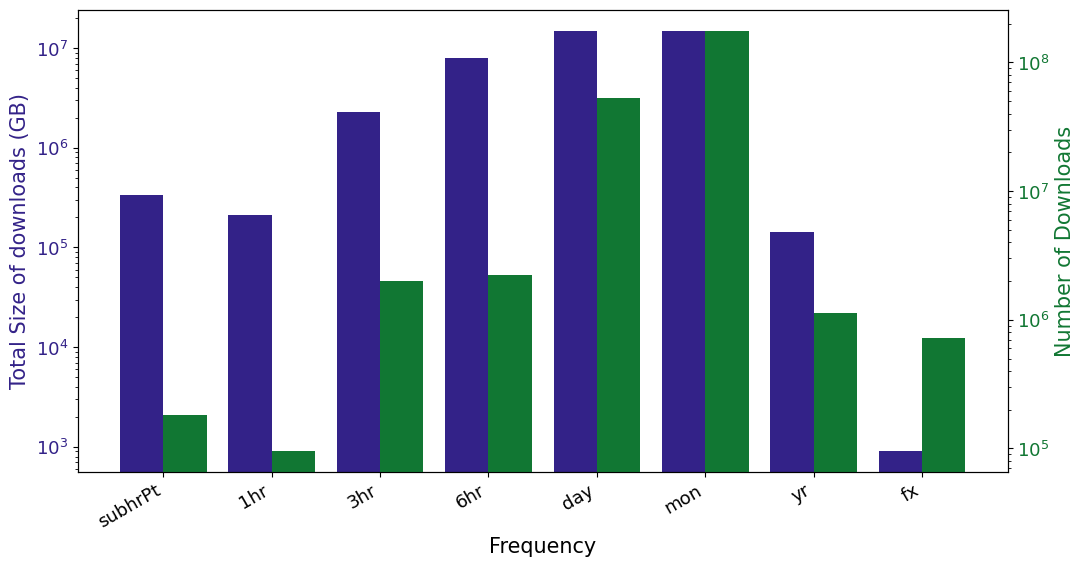

In [6]:
# Figure 4.1-1

freq_pie=df.groupby('freq', as_index=False).sum([["number_of_downloads",'total_size_GB']])
freq_pie=freq_pie.iloc[ [7,0, 1,2,3,6,8,5]]

fig, ax1, ax2=twinbarplot(
    list(freq_pie['total_size_GB']),
    list(freq_pie['number_of_downloads']),
    list(freq_pie['freq']),
    'Frequency',
)
fig.savefig('plots/ESGF_frequency.pdf',format='pdf', bbox_inches='tight',transparent=False)

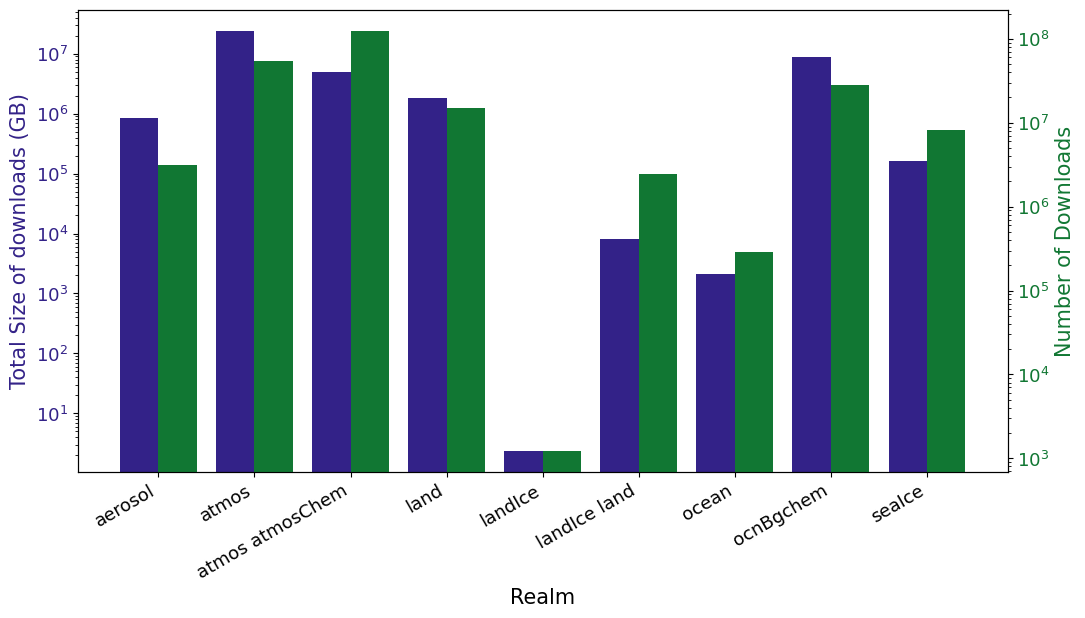

In [7]:
# Figure 4.1-2
freq_pie=df.groupby('realm', as_index=False).sum([["number_of_downloads",'total_size_GB']])

fig, ax1, ax2=twinbarplot(
    list(freq_pie['total_size_GB']),
    list(freq_pie['number_of_downloads']),
    list(freq_pie['realm']),
    'Realm',
)
fig.savefig('plots/ESGF_realm.pdf',format='pdf', bbox_inches='tight',transparent=False)

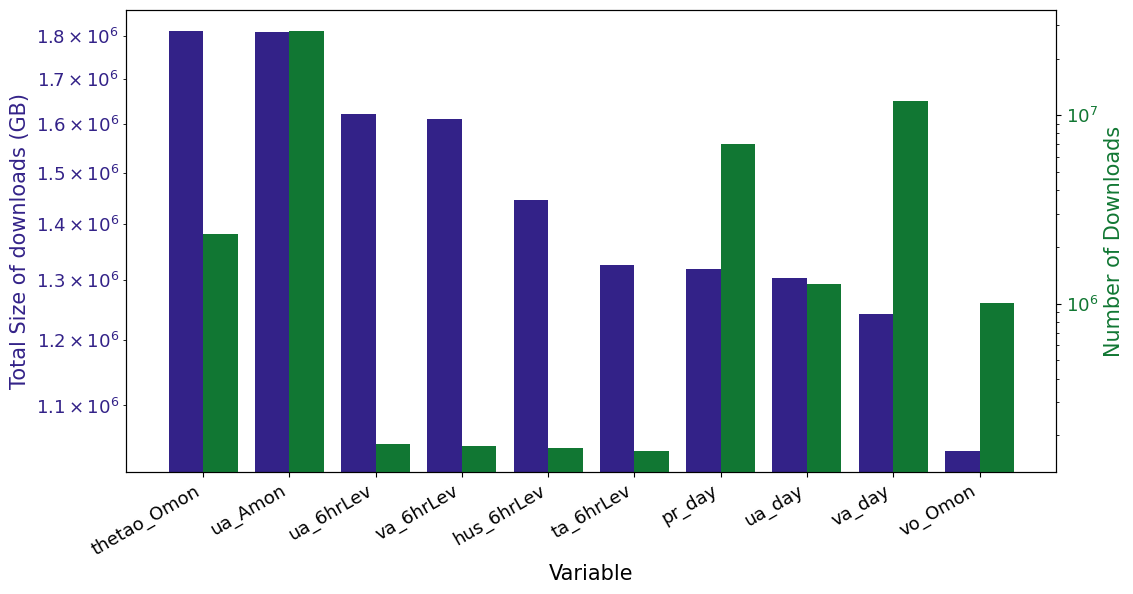

In [8]:
# Figure 4-1.3
n=10
fig, ax1, ax2=twinbarplot(
    list(df_gb[:n]['total_size_GB']),
    list(df_gb[:n]['number_of_downloads']),
    list(df_gb[:n]['unique']),
    'Variable',
)
fig.savefig('plots/ESGF_variable.pdf',format='pdf', bbox_inches='tight',transparent=False)

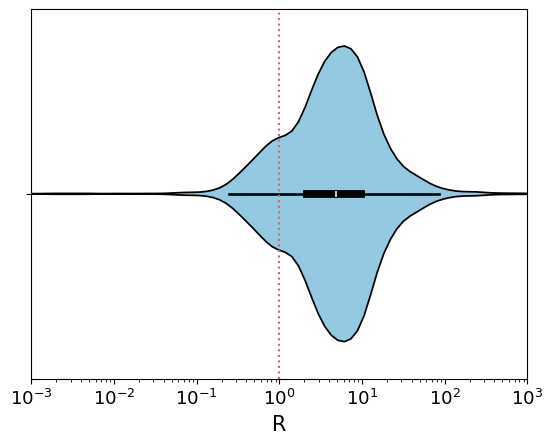

In [9]:
# Figure 4.1-4

plt.figure()
sns.violinplot(df['ratio_GB'][df['ratio_GB']!=0], orient='h', log_scale=True, color=colors[1],linecolor="k")#
plt.axvline(1, color=colors[6],linestyle=':')
plt.xlabel('R')
plt.xlim(1e-3, 1e3)
fig.savefig('plots/ESGF_R.pdf',format='pdf', bbox_inches='tight',transparent=False)

## stats

In [10]:
# total from cmcc
df_raw['number_of_downloads'].sum(),df_raw['total_size_GB'].sum()

(np.float64(236732332.0), np.float64(41731172.36000001))

In [11]:
#accepted tables and var
print('accepted CVs')
with open(f"data/CVs//CMIP6_table_id.json") as f:
    d = json.load(f)
    allowed_tables=d["table_id"]
print(len(allowed_tables), 'tables')
d_u={'mip_table':[],'variable_code':[],'upload_size_GB':[],'number_of_uploads':[]}
count=0
not_included=[]
for table in allowed_tables:
    with open(f"data/CVs/Tables/CMIP6_{table}.json") as f:
        d = json.load(f)
        allowed_var=d['variable_entry'].keys()
        count+=(len(allowed_var))
        for var in allowed_var:
            if f'{var.lower()}_{table}' not in list(df.unique):
                not_included.append(f'{var}_{table}')
print(count, "variables")
print(" valid on cmcc")
print(len(df),"variables")
print('diff')
print(count-len(df))
#print(not_included)

accepted CVs
43 tables
2062 variables
 valid on cmcc
1811 variables
diff
251


In [12]:
84+167

251

In [13]:
# what's going on with the difference
count=0
cmcc_data_nodes=["data_node=aims3.llnl.gov", "data.meteo.unican.es", "esg1.umr-cnrm.fr", "esg-dn1.nsc.liu.se", "esg-dn2.nsc.liu.se", "esg-dn3.nsc.liu.se", "esgf1.dkrz.de", "esgf3.dkrz.de", "esgf.bsc.es", "esgf-data1.llnl.gov", "esgf-data2.llnl.gov", "esgf-data3.ceda.ac.uk", "esgf-data3.llnl.gov", "esgf-data4.lnll.gov", "esgf-data7.ceda.ac.uk", "esgf-data.ucar.edu", "esgf.nci.org.au", "esgf-node2.cmcc.it", "vesg.ipsl.upmc.fr"]
not_uploaded=[]
for var in not_included:
    
    with urllib.request.urlopen(f"https://esgf-data.dkrz.de/esg-search/search/"\
                                            f"?limit=0&format=application%2Fsolr%2Bjson&mip_era=CMIP6&"\
                                            #"data_node=aims3.llnl.gov&data_node=data.meteo.unican.es&data_node=esg1.umr-cnrm.fr&data_node=esg-dn1.nsc.liu.se&data_node=esg-dn2.nsc.liu.se&data_node=esg-dn3.nsc.liu.se&data_node=esgf1.dkrz.de&data_node=esgf3.dkrz.de&data_node=esgf.bsc.es&data_node=esgf-data1.llnl.gov&data_node=esgf-data2.llnl.gov&data_node=esgf-data3.ceda.ac.uk&data_node=esgf-data3.llnl.gov&data_node=esgf-data4.lnll.gov&data_node=esgf-data7.ceda.ac.uk&data_node=esgf-data.ucar.edu&data_node=esgf.nci.org.au&data_node=esgf-node2.cmcc.it&data_node=vesg.ipsl.upmc.fr&"\
                                            f"variable_id={var.split('_')[0]}&facets=data_node,number_of_files&distrib=true") as url:
                    data = json.load(url)
                    node=data['facet_counts']['facet_fields']['data_node']
                    if len(node)==0:
                        count+=1
                        not_uploaded.append(var)
                    elif node in cmcc_data_nodes:
                        print(var, node, 'cmcc')
                        l_num=[num*int(x) for x, num in zip(data['facet_counts']['facet_fields']['number_of_files'][::2],
                                                              data['facet_counts']['facet_fields']['number_of_files'][1::2])]
                        print(np.sum(l_num))
                    else:
                        print(var, node, 'other')
                        l_num=[num*int(x) for x, num in zip(data['facet_counts']['facet_fields']['number_of_files'][::2],
                                                              data['facet_counts']['facet_fields']['number_of_files'][1::2])]
                        print(np.sum(l_num))
print('not on ESGF',count)
print(not_uploaded)                       

ta7h_6hrPlevPt ['esgf.ceda.ac.uk', 5] other
491
ua7h_6hrPlevPt ['esgf.ceda.ac.uk', 5] other
491
va7h_6hrPlevPt ['esgf.ceda.ac.uk', 5] other
491
wbptemp7h_6hrPlevPt ['esgf.ceda.ac.uk', 7] other
722
zg7h_6hrPlevPt ['esgf.ceda.ac.uk', 4] other
3120
h2o_CF3hr ['esg1.umr-cnrm.fr', 189, 'esgf3.dkrz.de', 356, 'vesg.ipsl.upmc.fr', 38] other
1114
reffclic_CF3hr ['esgf.ceda.ac.uk', 6, 'esgf3.dkrz.de', 35] other
76
reffclwc_CF3hr ['esgf.ceda.ac.uk', 6, 'esgf3.dkrz.de', 34] other
72
fco2fos_CFsubhr ['esg1.umr-cnrm.fr', 7, 'esgf.ceda.ac.uk', 24, 'esgf3.dkrz.de', 198] other
1291
psl_E1hr ['cmip.fio.org.cn', 46, 'esg-cccr.tropmet.res.in', 30, 'esg.camscma.cn', 25, 'esg1.umr-cnrm.fr', 5792, 'esgf-node2.cmcc.it', 6514, 'esgf.ceda.ac.uk', 25680, 'esgf.dwd.de', 1034, 'esgf.ichec.ie', 155, 'esgf.rcec.sinica.edu.tw', 1002, 'esgf1.dkrz.de', 4, 'esgf3.dkrz.de', 12893, 's3.eu-dkrz-1.dkrz.cloud', 1, 'vesg.ipsl.upmc.fr', 10767] other
342096
rlut_E1hr ['cmip.fio.org.cn', 45, 'esg-cccr.tropmet.res.in', 24, 'esg.c

In [14]:
# R stats
print(df[df['unique']=='ua_Amon']['ratio_GB'].values)
print(df[df['unique']=='rsu_Efx']['ratio_GB'].values)
print(df['ratio_GB'].mean())

print(df[df['unique']=='ua_Amon']['ratio_downloads'].values)
print(df[df['unique']=='rsu_Efx']['ratio_downloads'].values)
print(df['ratio_downloads'].mean())
print(df['ratio_downloads'].median())

[229.96527396]
[1411.38826272]
10.748761977397063
[954.97866976]
[1352.66666667]
20.592776834652206
5.368308766485648


In [15]:
# 0GB
len(df[df['total_size_GB']==0])

18

In [16]:
# not valid
print(df_raw['total_size_GB'].sum()-df['total_size_GB'].sum())
print(df_raw['number_of_downloads'].sum()-df['number_of_downloads'].sum())

1068548.300000012
782830.0


In [52]:
## CORDEX

df= pd.read_csv('data/cordex-variables_01_03_2025.csv')
print(df['total_size_GB'].sum(), df['number_of_downloads'].sum())

3319978.8399999994 9238679


## Appendix

In [18]:
pd.set_option('display.max_rows', 500) 
pd.set_option('display.precision', 2)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

df[df['ratio_GB']<1][['unique','total_size_GB','upload_size_GB','ratio_GB']]

,unique,total_size_GB,upload_size_GB,ratio_GB
5,aerasymbnd_E3hrPt,55.22,159.47,0.35
6,aeroptbnd_E3hrPt,40.67,266.16,0.15
7,aerssabnd_E3hrPt,61.78,159.51,0.39
14,albdiffbnd_E3hrPt,2.04,5.77,0.35
15,albdirbnd_E3hrPt,2.82,11.43,0.25
19,aoanh_AERmon,137.77,277.91,0.50
26,areacellr_fx,0.42,0.58,0.73
44,bigthetaoga_Odec,0.00,0.00,0.00
49,bs550aer_6hrLev,1.76,153.67,0.01
63,c2h6_AERmon,2439.59,3076.24,0.79


In [19]:

df[df['ratio_GB']>100][['unique','total_size_GB','upload_size_GB','ratio_GB']]

,unique,total_size_GB,upload_size_GB,ratio_GB
538,hfls_ImonAnt,93.78,0.84,111.04
991,pr_Amon,127177.93,671.58,189.37
996,pr_day,1318432.46,12598.20,104.65
1009,prhmax_Emon,26.27,0.12,217.07
1057,psl_Amon,54070.45,444.03,121.77
1105,rld_Efx,5.66,0.01,836.57
1129,rlu_Efx,5.77,0.01,543.23
1144,rlut_CF3hr,102.64,0.81,126.85
1165,rsd_Efx,5.78,0.01,413.34
1205,rsu_Efx,5.73,0.00,1411.39


In [20]:
pd.set_option('display.max_rows', 5000) 
pd.set_option('display.max_colwidth',500)
display(df_gb[:15][['unique','variable_long_name']])
display(df_gb[-15:][['unique','variable_long_name']])


,unique,variable_long_name
1521,thetao_Omon,Sea Water Potential Temperature
1643,ua_Amon,Eastward Wind
1639,ua_6hrLev,Eastward Wind
1676,va_6hrLev,Northward Wind
584,hus_6hrLev,Specific Humidity
1462,ta_6hrLev,Air Temperature
996,pr_day,Precipitation
1650,ua_day,Eastward Wind
1687,va_day,Northward Wind
1707,vo_Omon,Sea Water Y Velocity


,unique,variable_long_name
725,modelcellareai_IyrGre,The Cell Area of the Ice Sheet Model
1161,rootdsl_Efx,Root Distribution
602,iareagr_IyrGre,Area Covered by Grounded Ice Sheet
644,libmassbffl_IyrGre,Basal Specific Mass Balance Flux of Floating Ice Shelf
663,limnsw_IyrGre,Ice Sheet Mass That Does not Displace Sea Water
647,lim_IyrGre,Ice Sheet Mass
1396,snc_IyrGre,Snow Area Percentage
1439,sosga_Odec,Global Average Sea Surface Salinity
646,licalvf_IyrGre,Land Ice Calving Flux
1395,snc_IyrAnt,Snow Area Percentage


# Section 3.2 Experiment and activity

## Load and Clean Data

In [21]:
data_exp = pd.read_csv('data/ESGF/cmip6-experiments_13_01_2025.csv')
df_exp = pd.DataFrame(data_exp).iloc[:,:]

data_mip = pd.read_csv('data/CVs/cmip6_experiments_MIPs.csv', usecols = [0,1], nrows=270, skiprows=4)#, index_col=0) #index_col is chosen based on usecol subset
df_mip = pd.DataFrame(data_mip).iloc[:,:]

mip_column = df_mip['Activity']
df_expMIP = pd.concat([df_exp,mip_column], axis = 1)


In [22]:
# sorted according to number of downloads
df_expMIP_resort = df_expMIP.sort_values(by=['number_of_downloads'],ascending=False)

# split entries of experiments that are listed with multiple activities
df_expMIP_tmp=df_expMIP.sort_values(by=['Activity'])

df_expMIP_split=df_expMIP_tmp.assign(Activity=df_expMIP.Activity.str.split(',')).explode('Activity').dropna().reset_index(drop=True)
# remove leading space
df_expMIP_split.loc[df_expMIP_split['Activity'] == ' AerChemMIP','Activity']='AerChemMIP'
df_expMIP_split.loc[df_expMIP_split['Activity'] == ' LUMIP','Activity']='LUMIP'
df_expMIP_split.loc[df_expMIP_split['Activity'] == ' CDRMIP','Activity']='CDRMIP'

print(df_expMIP.Activity.unique())
print(df_expMIP_split.Activity.unique)
df_expMIP_split['% nod']=df_expMIP_split['number_of_downloads'] / df_expMIP_split.groupby('Activity')['number_of_downloads'].transform('sum')
df_expMIP_split['% tsGB']=df_expMIP_split['total_size_GB'] / df_expMIP_split.groupby('Activity')['total_size_GB'].transform('sum')

df_split_orig=copy.deepcopy(df_expMIP_split) # without introducing new lines for pie charts

df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'transient-deglaciation-prescribed-glac1d-methane', 'experiment_name'] = 'deglaciation\nglac1d-methane'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'transient-deglaciation-prescribed-glac1d', 'experiment_name'] = 'deglaciation\nglac1d'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'transient-deglaciation-prescribed-ice6g', 'experiment_name'] = 'deg.\nice6g'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'midpliocene-eoi400', 'experiment_name'] = 'midpliocene\neoi400'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == '1pctco2-cdr', 'experiment_name'] = '1pctco2\ncdr'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'esm-1pct-brch-1000pgc', 'experiment_name'] = 'esm-1pct\nbrch-1000pgc'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'abrupt-2xco2', 'experiment_name'] = 'abrupt\n2xco2'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'amip-4xco2', 'experiment_name'] = 'amip\n4xco2'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'piclim-histaer', 'experiment_name'] = 'piclim\nhistaer'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'piclim-histghg', 'experiment_name'] = 'piclim\nhistghg'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'highressst-future', 'experiment_name'] = 'highressst\nfuture'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'highres-future', 'experiment_name'] = 'highres\nfuture'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'control-1950', 'experiment_name'] = 'control\n1950'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'esm-1pct-brch-2000pgc', 'experiment_name'] = 'esm-1pct\nbrch-2000pgc'

['CMIP' 'ScenarioMIP' 'ScenarioMIP, AerChemMIP' 'HighResMIP' 'DCPP'
 'DAMIP' 'OMIP' 'PMIP' 'LUMIP' 'ISMIP6' 'AerChemMIP' 'PAMIP' 'C4MIP'
 'GMMIP' 'CFMIP' 'GeoMIP' 'LS3MIP' 'FAFMIP' 'C4MIP, CDRMIP'
 'LS3MIP, LUMIP' 'RFMIP, AerChemMIP' 'RFMIP' 'CDRMIP' nan 'VolMIP'
 'Palmod']
<bound method Series.unique of 0       AerChemMIP
1       AerChemMIP
2       AerChemMIP
3       AerChemMIP
4       AerChemMIP
5       AerChemMIP
6       AerChemMIP
7       AerChemMIP
8       AerChemMIP
9       AerChemMIP
10      AerChemMIP
11      AerChemMIP
12      AerChemMIP
13      AerChemMIP
14      AerChemMIP
15      AerChemMIP
16      AerChemMIP
17      AerChemMIP
18      AerChemMIP
19      AerChemMIP
20      AerChemMIP
21      AerChemMIP
22      AerChemMIP
23      AerChemMIP
24      AerChemMIP
25      AerChemMIP
26      AerChemMIP
27      AerChemMIP
28      AerChemMIP
29      AerChemMIP
30      AerChemMIP
31      AerChemMIP
32      AerChemMIP
33      AerChemMIP
34      AerChemMIP
35      AerChemMIP
36      Ae

In [23]:
# split entries of experiments that are listed with multiple activities
df_expMIP_resort_tmp=df_expMIP_resort.sort_values(by=['Activity']) # need to use resorted to keep sorting within an activity by number of downloads
df_expMIP_resort_split=df_expMIP_resort.assign(Activity=df_expMIP_resort.Activity.str.split(',')).explode('Activity').dropna().reset_index(drop=True)
# remove leading space
df_expMIP_resort_split.loc[df_expMIP_resort_split['Activity'] == ' AerChemMIP','Activity']='AerChemMIP'
df_expMIP_resort_split.loc[df_expMIP_resort_split['Activity'] == ' LUMIP','Activity']='LUMIP'
df_expMIP_resort_split.loc[df_expMIP_resort_split['Activity'] == ' CDRMIP','Activity']='CDRMIP'

print(df_expMIP_resort.Activity.unique())
print(df_expMIP_resort_split.Activity.unique)
df_expMIP_resort_split['% nod']=df_expMIP_resort_split['number_of_downloads'] / df_expMIP_resort_split.groupby('Activity')['number_of_downloads'].transform('sum')
df_expMIP_resort_split['% tsGB']=df_expMIP_resort_split['total_size_GB'] / df_expMIP_resort_split.groupby('Activity')['total_size_GB'].transform('sum')

df_resort_split_orig=copy.deepcopy(df_expMIP_resort_split) # without introducing new lines for pie charts

df_expMIP_resort_split.loc[df_expMIP_resort_split['experiment_name'] == 'transient-deglaciation-prescribed-glac1d-methane', 'experiment_name'] = 'deglaciation\nglac1d-methane'
df_expMIP_resort_split.loc[df_expMIP_resort_split['experiment_name'] == 'transient-deglaciation-prescribed-glac1d', 'experiment_name'] = 'deglaciation\nglac1d'
df_expMIP_resort_split.loc[df_expMIP_resort_split['experiment_name'] == 'transient-deglaciation-prescribed-ice6g', 'experiment_name'] = 'deglaciation\nice6g'
df_expMIP_resort_split.loc[df_expMIP_resort_split['experiment_name'] == 'midpliocene-eoi400', 'experiment_name'] = 'midpliocene\neoi400'
df_expMIP_resort_split.loc[df_expMIP_resort_split['experiment_name'] == '1pctco2-cdr', 'experiment_name'] = '1pctco2\ncdr'
df_expMIP_resort_split.loc[df_expMIP_resort_split['experiment_name'] == 'esm-1pct-brch-1000pgc', 'experiment_name'] = 'esm-1pct\nbrch-1000pgc'
df_expMIP_resort_split.loc[df_expMIP_resort_split['experiment_name'] == 'abrupt-2xco2', 'experiment_name'] = 'abrupt\n2xco2'
df_expMIP_resort_split.loc[df_expMIP_resort_split['experiment_name'] == 'amip-4xco2', 'experiment_name'] = 'amip\n4xco2'
df_expMIP_resort_split.loc[df_expMIP_resort_split['experiment_name'] == 'piclim-histaer', 'experiment_name'] = 'piclim\nhistaer'
df_expMIP_resort_split.loc[df_expMIP_resort_split['experiment_name'] == 'piclim-histghg', 'experiment_name'] = 'piclim\nhistghg'

['CMIP' 'ScenarioMIP' 'DCPP' 'ScenarioMIP, AerChemMIP' 'HighResMIP'
 'PAMIP' 'DAMIP' 'PMIP' 'ISMIP6' 'LUMIP' 'AerChemMIP' 'C4MIP' 'OMIP'
 'LS3MIP, LUMIP' 'LS3MIP' 'RFMIP, AerChemMIP' 'GeoMIP' 'RFMIP'
 'C4MIP, CDRMIP' 'GMMIP' 'CFMIP' 'FAFMIP' 'VolMIP' 'CDRMIP' nan 'Palmod']
<bound method Series.unique of 0             CMIP
1      ScenarioMIP
2             CMIP
3      ScenarioMIP
4             DCPP
5      ScenarioMIP
6       AerChemMIP
7      ScenarioMIP
8             CMIP
9       HighResMIP
10            CMIP
11     ScenarioMIP
12      HighResMIP
13      HighResMIP
14      HighResMIP
15            CMIP
16     ScenarioMIP
17     ScenarioMIP
18     ScenarioMIP
19           PAMIP
20           PAMIP
21      HighResMIP
22           DAMIP
23           DAMIP
24           DAMIP
25            PMIP
26          ISMIP6
27            CMIP
28            PMIP
29           LUMIP
30            PMIP
31            CMIP
32      AerChemMIP
33           PAMIP
34           C4MIP
35            DCPP
36         

In [24]:
labels_mip = df_expMIP_split['Activity'].unique()
dfs_mip= []
dict_mip = {}
for l in labels_mip:

    tmp=df_expMIP_resort_split[df_expMIP_resort_split['Activity']==l]
    tmp2 = tmp[tmp['% nod']>=0.1]
    tmp3 = tmp[tmp['% nod']<0.1]
    n_o=len(tmp3)
    new_row = pd.DataFrame(data = {'experiment_name' : ['others (%d)' % (n_o)],
                                   'number_of_downloads' : [tmp3['number_of_downloads'].sum()], 
                                   'total_size_GB': [tmp3['total_size_GB'].sum()], 
                                   '% nod': [tmp3['% nod'].sum()],
                                   'Activity' : [l]})
    df = pd.concat([tmp2,new_row])
    if l=='PMIP':
        print(tmp2)

    dfs_mip.append(df)
    dict_mip.update({l: np.asarray(df['% nod'].values)})

        experiment_name  number_of_downloads  total_size_GB Activity  % nod  \
25          midholocene               533338      100944.93     PMIP   0.30   
28              lig127k               412731       80358.84     PMIP   0.23   
30             past1000               375417       21527.37     PMIP   0.21   
44  midpliocene\neoi400               182235       44595.41     PMIP   0.10   

    % tsGB  
25    0.33  
28    0.26  
30    0.07  
44    0.15  


In [25]:
dfs_mip_size= []
dict_mip_size = {}
for l in labels_mip:
    tmp=df_expMIP_split[df_expMIP_split['Activity']==l]
    tmp2 = tmp[tmp['% tsGB']>=0.1]
    tmp3 = tmp[tmp['% tsGB']<0.1]
    n_o=len(tmp3)
    new_row = pd.DataFrame(data = {'experiment_name' : ['others (%d)' % (n_o)],
                                   'number_of_downloads' : [tmp3['number_of_downloads'].sum()], 
                                   'total_size_GB': [tmp3['total_size_GB'].sum()], '% tsGB': [tmp3['% tsGB'].sum()],
                                   'Activity' : [l]})
    if l=='PMIP':
        print(tmp2)

    df = pd.concat([tmp2,new_row])
    dfs_mip_size.append(df)
    dict_mip_size.update({l: np.asarray(df['% tsGB'].values)})

         experiment_name  number_of_downloads  total_size_GB Activity  % nod  \
225                  lgm               139524       36114.90     PMIP   0.08   
226  midpliocene\neoi400               182235       44595.41     PMIP   0.10   
227              lig127k               412731       80358.84     PMIP   0.23   
230          midholocene               533338      100944.93     PMIP   0.30   

     % tsGB  
225    0.12  
226    0.15  
227    0.26  
230    0.33  


## Figures

In [26]:
import textwrap
def wrap_labels(ax, width, break_long_words=False):
    labels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        labels.append(textwrap.fill(text, width=width,
                      break_long_words=break_long_words))
    ax.set_xticklabels(labels, rotation=0)

def plotBar(ax,results,exp_names,label_rot=0,xlabel_fs=20,barlabel_fs=10,xticks_fs=20,yticks_fs=20,hideYlabels=False):
    """
    Parameters
    ----------
    results : dict
        A mapping from question labels to a list of answers per category.
        It is assumed all lists contain the same number of entries and that
        it matches the length of *category_names*.
    category_names : list of str
        The category labels.
    """
    labels = list(results.keys())
    data = list(results.values())
    data_cs, starts = [],[]
    cmap = plt.get_cmap('YlGnBu')
    category_colors = []
    for d in data:
        tmp=d.cumsum()
        data_cs.append(tmp)
        category_colors.append([cmap(i) for i in np.linspace(0.05, 0.75, d.shape[0])])
        starts.append(tmp-d)

#    fig, ax = plt.subplots(figsize=(9.2, 15))
    ax.invert_yaxis()
    ax.set_xlim(0, 1)

    for i, (l,color,d,d_c,start,df) in enumerate(zip(labels,category_colors,data,data_cs,starts,exp_names)):
        rects = ax.barh(l, d, left=start, height=0.5,
                        label=l, color=color)
        ax.tick_params(axis="y",labelsize=yticks_fs, length=5, width=1, color ='black', direction='out')
        text_color = 'k'
        ax.set_xticks(np.arange(0,1.1,0.1))
        if hideYlabels==True:
            ax.set_yticklabels('')
        ax.set_xticklabels(range(0,110,10),fontsize=xticks_fs)
        ax.set_xlabel("percentage of number of downloads [%]",fontsize=xlabel_fs)
        ax.tick_params(axis='x', length=5, width=1, color ='black', direction='out')
        ax.bar_label(rects, labels=df['experiment_name'].values, label_type='center', color=text_color,rotation=label_rot,fontsize=barlabel_fs)
    #ax.legend(ncol=len(category_names), bbox_to_anchor=(0, 1),
    #          loc='lower left', fontsize='small')

    wrap_labels(ax,10)

    return fig, ax

In [27]:
def plotBar_size(ax,results,exp_names,label_rot=0,xlabel_fs=20,barlabel_fs=10,xticks_fs=20,yticks_fs=20,hideYlabels=False):
    """
    Parameters
    ----------
    results : dict
        A mapping from question labels to a list of answers per category.
        It is assumed all lists contain the same number of entries and that
        it matches the length of *category_names*.
    category_names : list of str
        The category labels.
    """
    labels = list(results.keys())
    data = list(results.values())
    data_cs, starts = [],[]
    cmap = plt.get_cmap('YlGnBu')
    category_colors = []
    for d in data:
        tmp=d.cumsum()
        data_cs.append(tmp)
        category_colors.append([cmap(i) for i in np.linspace(0.05, 0.75, d.shape[0])])
        starts.append(tmp-d)

    ax.invert_yaxis()
    ax.set_xlim(0, 1)

    for i, (l,color,d,d_c,start,df) in enumerate(zip(labels,category_colors,data,data_cs,starts,exp_names)):
        rects = ax.barh(l, d, left=start, height=0.5,
                        label=l, color=color)
        ax.tick_params(axis="y",labelsize=yticks_fs, length=5, width=1, color ='black', direction='out')
        text_color = 'k'
        ax.set_xticks(np.arange(0,1.1,0.1))
        if hideYlabels==True:
            ax.set_yticklabels('')
        ax.set_xticklabels(range(0,110,10),fontsize=xticks_fs)
        ax.set_xlabel("percentage of size of downloads [%]",fontsize=xlabel_fs)
        ax.tick_params(axis='x', length=5, width=1, color ='black', direction='out')
        ax.bar_label(rects, labels=df['experiment_name'].values, label_type='center', color=text_color,rotation=label_rot,fontsize=barlabel_fs)
    #ax.legend(ncol=len(category_names), bbox_to_anchor=(0, 1),
    #          loc='lower left', fontsize='small')

    wrap_labels(ax,10)

    return fig, ax


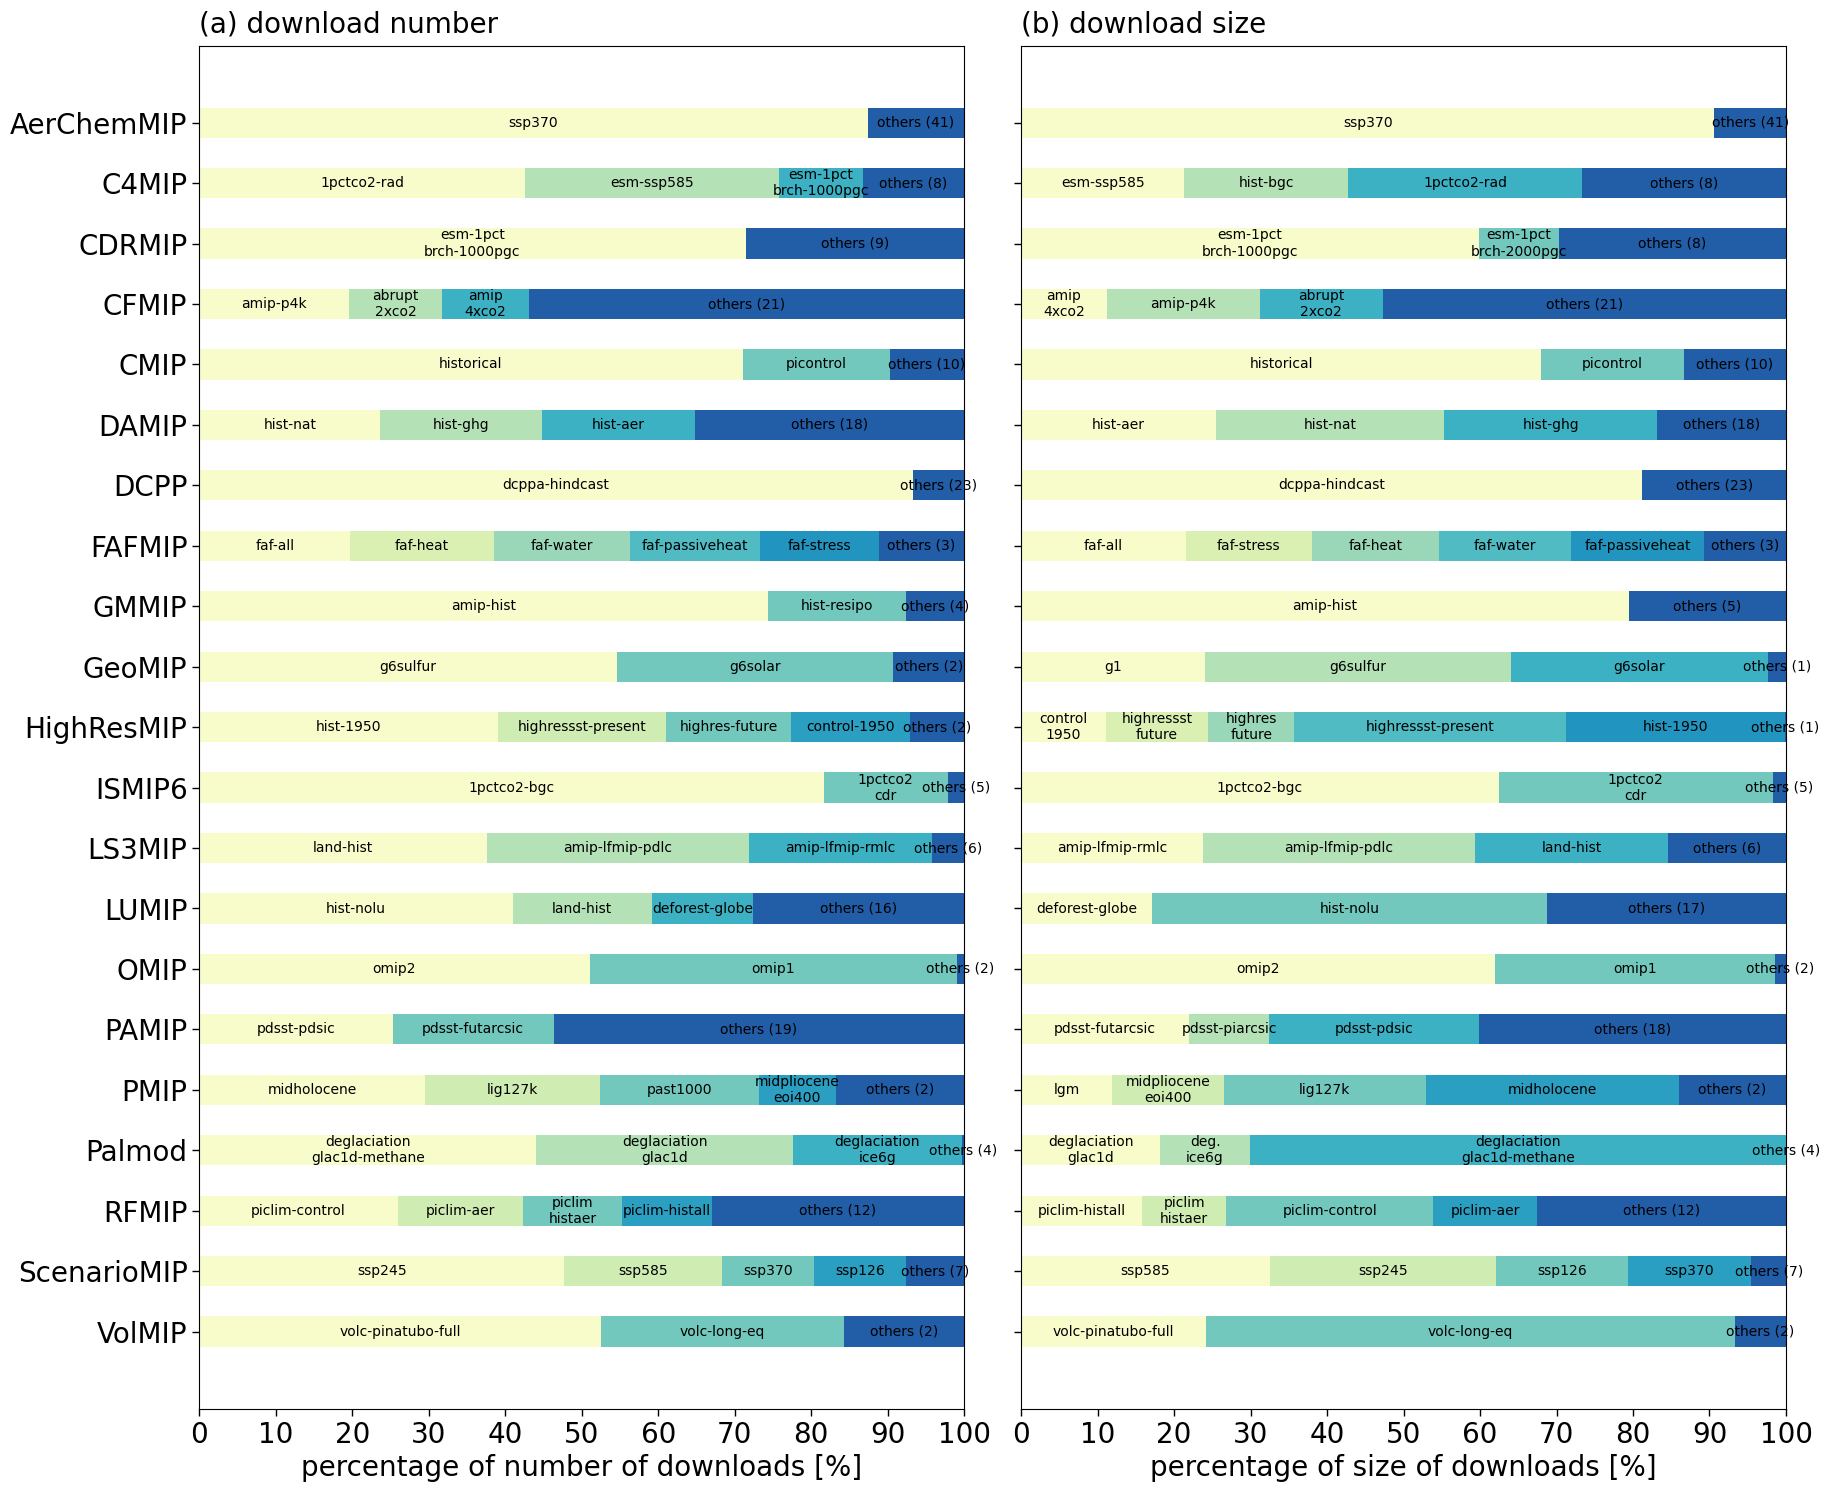

In [28]:
fig, ax = plt.subplots(ncols=2,nrows=1,figsize=(18.4, 15))
#figname=plot_dir+'exp_per_mip_barh_download_size'
plotBar(ax[0],dict_mip,dfs_mip,label_rot=0)
plotBar_size(ax[1],dict_mip_size,dfs_mip_size,hideYlabels=True)
ax[0].text(0., 1.01, '(a) download number', transform = ax[0].transAxes,fontsize=20)
ax[1].text(0., 1.01, '(b) download size', transform = ax[1].transAxes,fontsize=20)
plt.tight_layout()


plt.show()
fig.savefig('plots/ESGF_experiment.pdf',format='pdf', bbox_inches='tight',transparent=False)

In [29]:
mip_sum = []
mip_nDown = []
mip_nSize = []
for n in labels_mip:
    tmp=df_expMIP.dropna()[df_expMIP.dropna()['Activity'].str.contains(n)].sum()
    tmp['Activity']=n
    mip_sum.append(tmp)
    mip_nDown.append(tmp['number_of_downloads'])
    mip_nSize.append(tmp['total_size_GB'])

df_mip_cmp = pd.DataFrame(
    {'mip_name': labels_mip,
     'number_of_downloads': mip_nDown,
     'total_size_GB': mip_nSize
    })
df_mip_cmp_resort=df_mip_cmp.sort_values(by=['total_size_GB'],ascending=False)


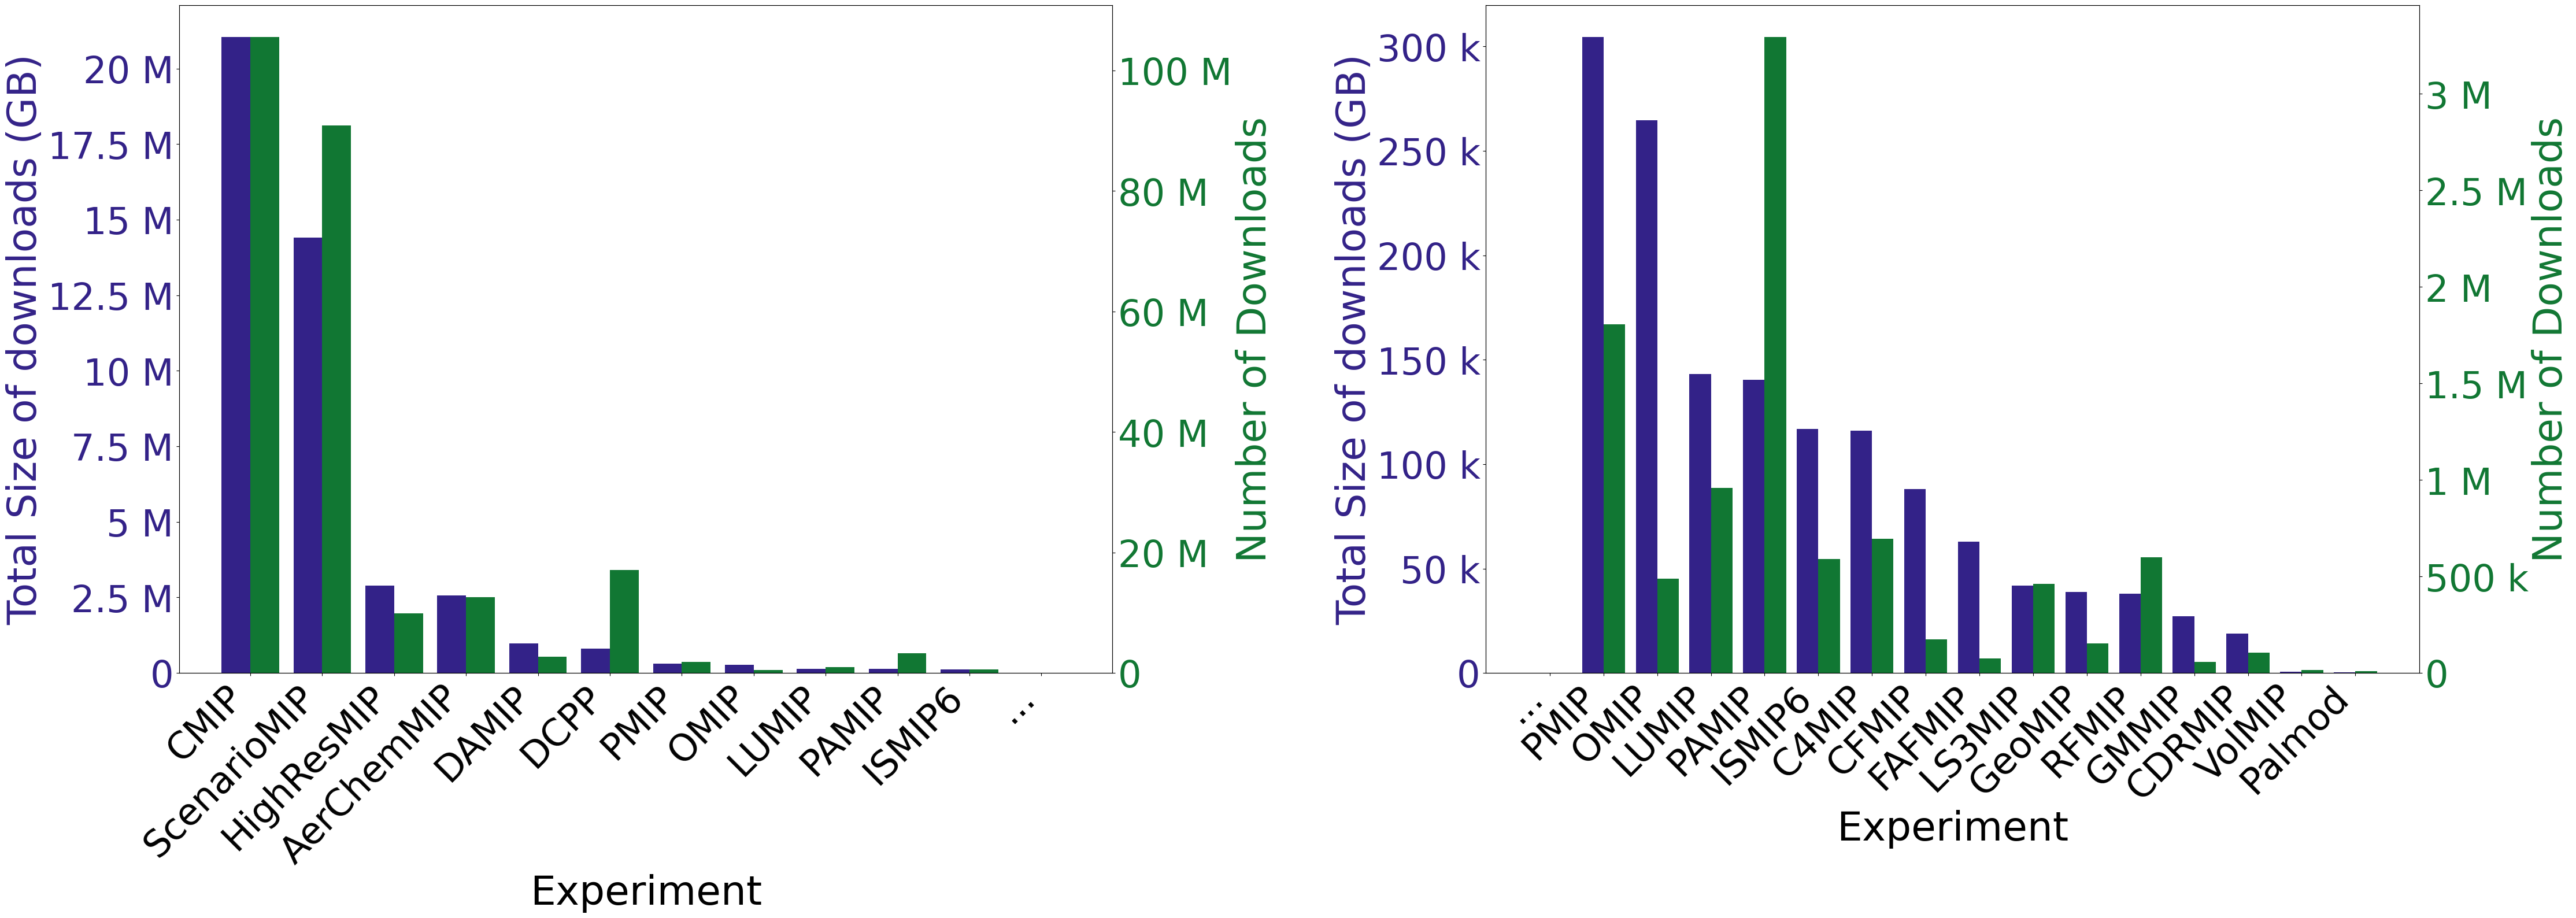

In [30]:
fig, axs = plt.subplots(nrows=1,ncols=2, figsize=(50.0, 15.0))

from matplotlib.ticker import EngFormatter

fmt = EngFormatter(unit="")


start_idx=6
end_idx=11
fig, ax1, ax2=twinbarplot(
    list(df_mip_cmp_resort['total_size_GB'][:end_idx])+[0],
    list(df_mip_cmp_resort['number_of_downloads'][:end_idx])+[0],
    list(df_mip_cmp_resort['mip_name'][:end_idx])+['...'],
    'Experiment',
    ax=(fig,axs[0]),
    log=False,
    
)



tickx=46
ticky=46
labelx=50
labely=50

ax1.tick_params(axis='x', labelsize=tickx)
ax1.tick_params(axis='y', labelsize=ticky)
ax2.tick_params(axis='y', labelsize=ticky)
ax1.xaxis.label.set_size(labelx)
ax1.yaxis.label.set_size(labely)
ax2.yaxis.label.set_size(labely)
ax1.yaxis.set_major_formatter(fmt)
ax2.yaxis.set_major_formatter(fmt)
ax1.tick_params(axis='x', labelrotation=45)


fig, ax1, ax2=twinbarplot(
    [0]+list(df_mip_cmp_resort['total_size_GB'][start_idx:]),
    [0]+list(df_mip_cmp_resort['number_of_downloads'][start_idx:]),
    ['...']+list(df_mip_cmp_resort['mip_name'][start_idx:]),
    'Experiment',
    ax=(fig,axs[1]),
    log=False
)

ax1.tick_params(axis='x', labelsize=tickx)
ax1.tick_params(axis='y', labelsize=ticky)
ax2.tick_params(axis='y', labelsize=ticky)
ax1.xaxis.label.set_size(labelx)
ax1.yaxis.label.set_size(labely)
ax2.yaxis.label.set_size(labely)
ax1.tick_params(axis='x', labelrotation=45)

ax1.yaxis.set_major_formatter(fmt)
ax2.yaxis.set_major_formatter(fmt)

plt.subplots_adjust(wspace=0.4) 
fig.savefig('plots/ESGF_activity.pdf',format='pdf', bbox_inches='tight',transparent=False)

# Section 3.3 Source and institution

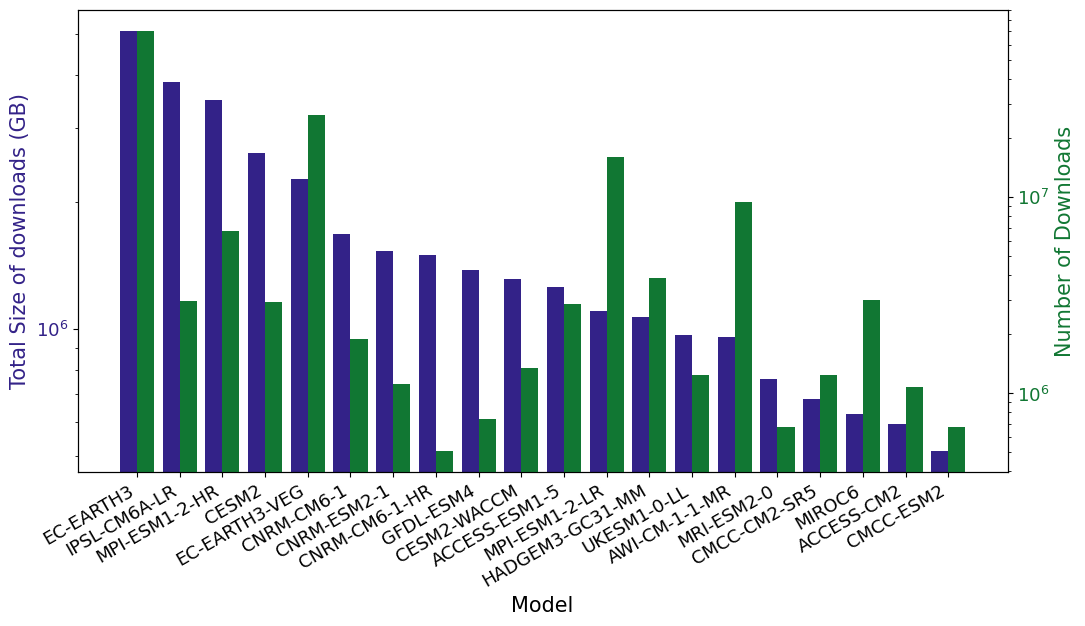

In [31]:
df= pd.read_csv(f"data/ESGF/cmip6-sources_13_01_2025.csv")
# put in order of popularity
df_source_gb=df.sort_values('total_size_GB', ascending=False)

n=20
fig, ax1, ax2=twinbarplot(
    list(df_source_gb[:n]['total_size_GB']),
    list(df_source_gb[:n]['number_of_downloads']),
    list(df_source_gb[:n]['source_id_name']),
    'Model',
)
fig.savefig('plots/ESGF_model.pdf',format='pdf', bbox_inches='tight',transparent=False)

# Section 3.4 Country and Continent

## Load and clean data

In [32]:
# Filenames
downloadsByCountry_file = "data/ESGF/CMIP6downloadsByCountry_13_01_2025.csv"
downloadsByHost_file = ""
dataByInstitute_file = "data/ESGF/cmip6-institutes_13_01_2025.csv"

# Remove strange characters from CSV files
for file in [downloadsByCountry_file, dataByInstitute_file]:
    with open(file, "r", encoding="utf-8", errors="replace") as f:
        content = f.read()
    with open(file, "w", encoding="utf-8") as f:
        f.write(content)

# Load CSV files
downloadsByCountry = pd.read_csv(downloadsByCountry_file, encoding="utf-8")  
downloadsByHost = ""
dataByInstitute = pd.read_csv(dataByInstitute_file, encoding="utf-8") 

# Display first few rows
print(downloadsByCountry.head())
print("=====")
print(dataByInstitute.head())

   num_downloads  downloaded_data  country
0       39597081      11168000.68      USA
1       68623384       3480519.00    China
2        8386889       1603986.37   France
3        6005376       1532490.41       UK
4        3395586       1376526.45  Germany
=====
  Institute  Country  number_of_datasets  total_size_TB
0       AER      USA                  24           0.00
1   AS-RCEC   Taiwan              106780         245.69
2       AWI  Germany              146457         335.52
3       BCC    Spain              142028         407.61
4      CAMS    China                6807          25.37


In [33]:
# Split up EC-Earth into 6 countries:
EC_Earth_totSize = dataByInstitute[dataByInstitute['Institute'] == "EC-Earth-Consortium"]['total_size_TB'].iloc[0]
EC_Earth_totSize_div7 = round(EC_Earth_totSize/7., 2)

# Assign one seventh of EC-Earth published data to the main EC-Earth core partners
for country in ['Sweden', 'Netherlands', 'Denmark', 'Spain', 'Ireland', 'Italy', 'Finland']:
    new_row = pd.DataFrame({'Institute': ['EC-Earth-Consortium'], 'Country': [country], 
                            'number_of_datasets': [np.nan], 'total_size_TB': [EC_Earth_totSize_div7]})
    dataByInstitute = pd.concat([dataByInstitute, new_row], ignore_index=True)

dataByInstitute = dataByInstitute[(dataByInstitute['Institute'] != "EC-Earth-Consortium") | (dataByInstitute['Institute'] != "Europe")]

print(dataByInstitute.head())

  Institute  Country  number_of_datasets  total_size_TB
0       AER      USA               24.00           0.00
1   AS-RCEC   Taiwan           106780.00         245.69
2       AWI  Germany           146457.00         335.52
3       BCC    Spain           142028.00         407.61
4      CAMS    China             6807.00          25.37


In [34]:
# Find common countries in downloads by Institute and by country:
common_elements_CountryInstitute = sorted(set(downloadsByCountry["country"]) & set(dataByInstitute["Country"]))
downloadsCountryAndInstitute = pd.DataFrame({
    'country': common_elements_CountryInstitute,
    'downCountry': 0.,
    'downHost' : 0.
})

for ii, country in enumerate(common_elements_CountryInstitute): 
    downloadsCountryAndInstitute.loc[ii, "downCountry"] = downloadsByCountry[downloadsByCountry['country'] == country]['downloaded_data'].sum()
    downloadsCountryAndInstitute.loc[ii, "downInst"] = dataByInstitute[dataByInstitute['Country'] == country]['total_size_TB'].sum()*1.e3

downloadsCountryAndInstitute["ratioInstCountry"] = downloadsCountryAndInstitute["downInst"]/downloadsCountryAndInstitute["downCountry"]

downloadsCountryAndInstitute

,country,downCountry,downHost,downInst,ratioInstCountry
0,Australia,742126.28,0.00,866250.00,1.17
1,Canada,475912.98,0.00,974790.00,2.05
2,China,3480519.00,0.00,683390.00,0.20
3,Denmark,40217.60,0.00,554720.00,13.79
4,Finland,25837.55,0.00,554720.00,21.47
5,France,1603986.37,0.00,5882140.00,3.67
6,Germany,1376526.45,0.00,4093380.00,2.97
7,India,378357.34,0.00,79890.00,0.21
8,Ireland,61481.00,0.00,554720.00,9.02
9,Italy,321525.68,0.00,1174320.00,3.65


In [35]:
# Re-do analysis by continent

# Filenames
downloadsByContinent_file = "data/ESGF/CMIP6downloadsByContinent_13_01_2025.csv"

# Remove weird characters from CSV files
for file in [downloadsByContinent_file]:
    with open(file, "r", encoding="utf-8", errors="replace") as f:
        content = f.read()
    with open(file, "w", encoding="utf-8") as f:
        f.write(content)

# Load CSV files
downloadsByContinent = pd.read_csv(downloadsByContinent_file, encoding="utf-8")  

downloadsByContinent = downloadsByContinent.sort_values(by='continent')

# Display first few rows
print(downloadsByContinent)

# Create Dataframe combining the data

downloadsContinentAndInst = pd.DataFrame({
    'continent': downloadsByContinent['continent'],
    'downContinent': downloadsByContinent['downloaded_data'],
    'downHost' : 0.
})

downloadsContinentAndInst.loc[downloadsContinentAndInst['continent'] == 'North America', "downInst"] = (
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'USA']['downInst'].sum() + 
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'Canada']['downInst'].sum())

downloadsContinentAndInst.loc[downloadsContinentAndInst['continent'] == 'Oceania', "downInst"] = (
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'Australia']['downInst'].sum() + 
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'New Zealand']['downInst'].sum())

downloadsContinentAndInst.loc[downloadsContinentAndInst['continent'] == 'Europe', "downInst"] = (
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'France']['downInst'].sum() + 
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'Germany']['downInst'].sum() + 
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'Italy']['downInst'].sum() + 
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'Spain']['downInst'].sum() + 
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'UK']['downInst'].sum() + 
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'Norway']['downInst'].sum() + 
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'Russia']['downInst'].sum() + 
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'Netherlands']['downInst'].sum() + 
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'Denmark']['downInst'].sum() + 
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'Ireland']['downInst'].sum() + 
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'Finland']['downInst'].sum() + 
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'Sweden']['downInst'].sum())

downloadsContinentAndInst.loc[downloadsContinentAndInst['continent'] == 'Asia', "downInst"] = (
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'China']['downInst'].sum() + 
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'India']['downInst'].sum() + 
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'Korea']['downInst'].sum() + 
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'Taiwan']['downInst'].sum() + 
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'Japan']['downInst'].sum())

downloadsContinentAndInst['downContinent'] = round(downloadsContinentAndInst['downContinent'], 1)
downloadsContinentAndInst['downInst'] = round(downloadsContinentAndInst['downInst'], 1)

downloadsContinentAndInst['downInst'] = downloadsContinentAndInst['downInst'].fillna(0)

downloadsContinentAndInst['ContInst_ratio'] = round(downloadsContinentAndInst['downContinent'] / downloadsContinentAndInst['downInst'], 2)

downloadsContinentAndInst['ContInst_ratio'] = downloadsContinentAndInst['ContInst_ratio'].replace([np.inf, -np.inf], np.nan)
 
downloadsContinentAndInst = downloadsContinentAndInst[downloadsContinentAndInst['continent'] != "Antarctica"]

print(downloadsContinentAndInst)
print("======")
print("Sum downContinent: ",  round(downloadsContinentAndInst['downContinent'].sum(), 1), ", sum downInst: ", round(downloadsContinentAndInst['downInst'].sum(), 1))


   num_downloads  downloaded_data      continent
5         578151        171900.87         Africa
6           3239            47.74     Antarctica
2       88906060       7449871.77           Asia
1       38539823       8145544.55         Europe
0       43171986      11678357.94  North America
3        2902700        894903.07        Oceania
4        1281940        281575.56  South America
       continent  downContinent  downHost    downInst  ContInst_ratio
5         Africa      171900.90      0.00        0.00             NaN
2           Asia     7449871.80      0.00  4819530.00            1.55
1         Europe     8145544.60      0.00 18134900.00            0.45
0  North America    11678357.90      0.00  3229880.00            3.62
3        Oceania      894903.10      0.00   872370.00            1.03
4  South America      281575.60      0.00        0.00             NaN
Sum downContinent:  28622153.9 , sum downInst:  27056680.0


## Figures

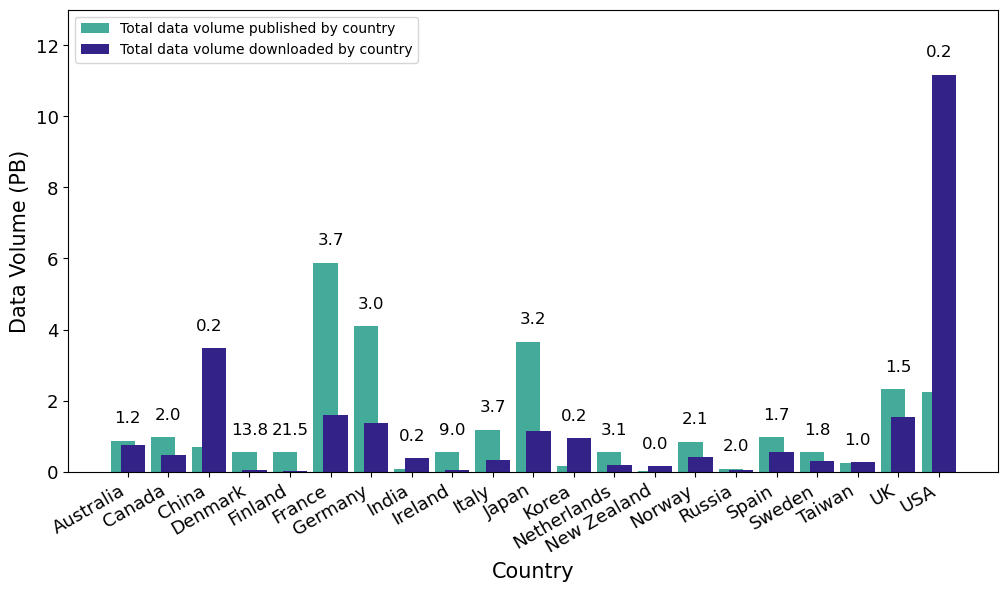

In [36]:
# Plot

# Plot settings
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(downloadsCountryAndInstitute['country']))  # X-axis positions
width = 0.6  # Bar width

# Plot 'downInst' bars on top of 'downCountry'
bars2 = ax.bar(x-0.125, downloadsCountryAndInstitute['downInst']/1e6, width, label='Total data volume published by country', color=colors[2])

# Plot 'downCountry' bars
bars1 = ax.bar(x+0.125, downloadsCountryAndInstitute['downCountry']/1e6, width, label='Total data volume downloaded by country', color=colors[0])

# Annotate ratioInstCountry above bars
for i, (bar1, bar2, ratio) in enumerate(zip(bars1, bars2, downloadsCountryAndInstitute['ratioInstCountry'])):
    height = max(bar2.get_height(), bar1.get_height())
    ax.text(bar1.get_x() + bar1.get_width()/2 -0.125, height + .5, f'{ratio:.1f}', ha='center', fontsize=12) #, fontweight='bold')

# Labels and legend
ax.set_xlabel("Country")
ax.set_ylabel("Data Volume (PB)")
ax.set_title("")
ax.set_xticks(x)
plt.xticks( rotation=30, ha='right')  
plt.ylim(0, 13) 
ax.set_xticklabels(downloadsCountryAndInstitute['country'])
ax.legend()

# Show plot
plt.show()
fig.savefig('plots/ESGF_country.pdf',format='pdf', bbox_inches='tight',transparent=False)

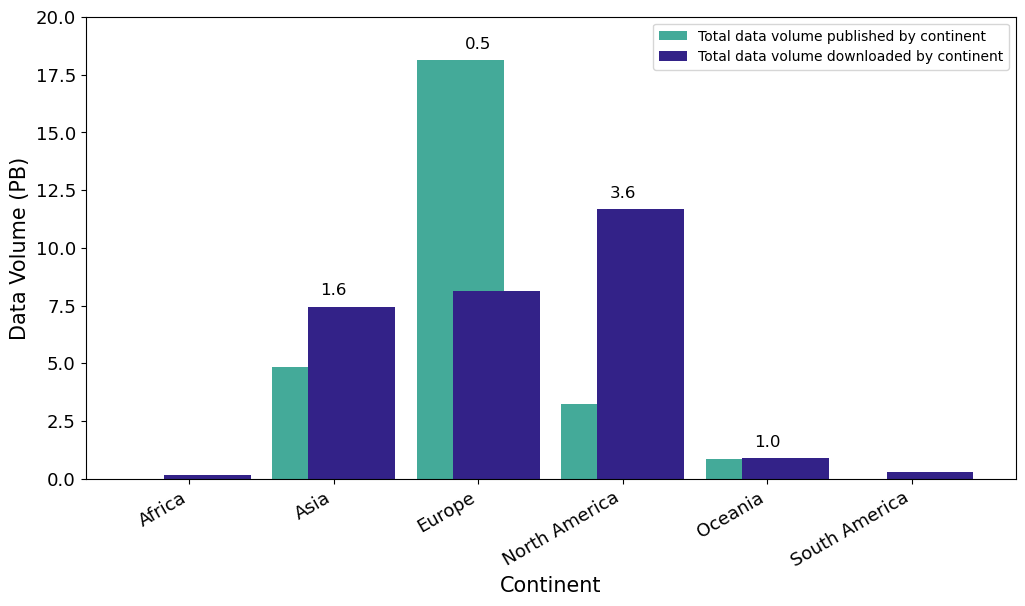

In [37]:
# Plot

# Plot settings
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(downloadsContinentAndInst['continent']))  # X-axis positions
width = 0.6  # Bar width

# Plot 'downInst' bars on top of 'downContinent'
bars2 = ax.bar(x-0.125, downloadsContinentAndInst['downInst']/1e6, width, label='Total data volume published by continent', color=colors[2])

# Plot 'downContinent' bars
bars1 = ax.bar(x+0.125, downloadsContinentAndInst['downContinent']/1e6, width, label='Total data volume downloaded by continent', color=colors[0])

# Annotate ratioInstContinent above bars
for i, (bar1, bar2, ratio) in enumerate(zip(bars1, bars2, downloadsContinentAndInst['ContInst_ratio'])):
    if not np.isnan(ratio):
        height = max(bar2.get_height(), bar1.get_height())
        ax.text(bar1.get_x() + bar1.get_width()/2 -0.125, height + .5, f'{ratio:.1f}', ha='center', fontsize=12) #, fontweight='bold')

# Labels and legend
ax.set_xlabel("Continent")
ax.set_ylabel("Data Volume (PB)")
ax.set_title("")
ax.set_xticks(x)
plt.xticks( rotation=30, ha='right')  
plt.ylim(0, 20) 
ax.set_xticklabels(downloadsContinentAndInst['continent'])
ax.legend()

# Show plot
plt.show()
fig.savefig('plots/ESGF_continent.pdf',format='pdf', bbox_inches='tight',transparent=False)

## Section 3.4.2 per capita country usage

In [38]:
# get population data
country_populations = pd.read_csv('data/country_populations_WorldBank/API_SP.POP.TOTL_DS2_en_csv_v2_246068.csv', skiprows=4)
#country_populations['Country Name'].unique()

# get download data, ESGF
df_cld = pd.read_csv('data/ESGF/CMIP6downloadsByCountry_13_01_2025.csv')


# manual renaming of some countries: 
country_mapping = {
    # Naming Differences and Abbreviations
    'United States': 'USA',
    'United Kingdom': 'UK',
    'Russian Federation': 'Russia',
    'Czechia': 'Czech Republic',
    'Lao PDR': 'Laos',
    "Cote d'Ivoire": "Cote d'Ivoire",  # Identical, included for clarity
    'Brunei Darussalam': 'Brunei Darussalam', # Identical, included for clarity
    'Bosnia and Herzegovina': 'Serbia', # Best practical match in List 2, as Bosnia isn't separate
    'Slovak Republic': 'Slovakia',
    'Congo, Dem. Rep.': 'Congo (Kinshasa)', # Common mapping for DRC
    'Dominican Republic': 'Dominican Republic', # Identical, included for clarity
    'Egypt, Arab Rep.': 'Egypt',
    'Iran, Islamic Rep.': 'Iran',
    'Kyrgyz Republic': 'Kyrgyzstan',
    'Korea, Rep.': 'Korea',
    'St. Kitts and Nevis': 'Saint Kitts and Nevis',
    'St. Lucia': 'Saint Lucia',
    'North Macedonia': 'Macedonia',
    'Eswatini': 'Swaziland', # Older name is used in List 2
    'Syrian Arab Republic': 'Syria', # Not in List 2, using closest general name
    'Venezuela, RB': 'Venezuela',
    'Yemen, Rep.': 'Yemen', # Not in List 2, using closest general name
    'Viet Nam': 'Vietnam',
    'Turkiye': 'Turkey',
    'Bahamas, The': 'Bahamas',
    'Gambia, The': 'Gambia',
    'Hong Kong SAR, China': 'Hong Kong',
    'Somalia, Fed. Rep.':'Somalia',
}

country_populations['Country Name'] = country_populations['Country Name'].replace(country_mapping)


In [39]:
#country_populations

In [40]:

# add population data to download stats
population_dict = dict(zip(country_populations['Country Name'], country_populations['2024']))
df_cld['population'] = df_cld['country'].map(population_dict)

df_cld['downloads_per_capita'] = df_cld['num_downloads']/df_cld['population']
# check non-mapped countries:
print(df_cld[pd.isna(df_cld['population'])]['country'])

# not everything aligned, but mostly small places, so I'm accepting these NaNs

17            Taiwan
58           Reunion
71             Macau
102        Palestine
110       Antarctica
115    Aland Islands
124      Puerto Rico
128     Vatican City
154       Cape Verde
162         Guernsey
Name: country, dtype: object


/tmp/ipykernel_1549/274199834.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right')
/tmp/ipykernel_1549/274199834.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right')


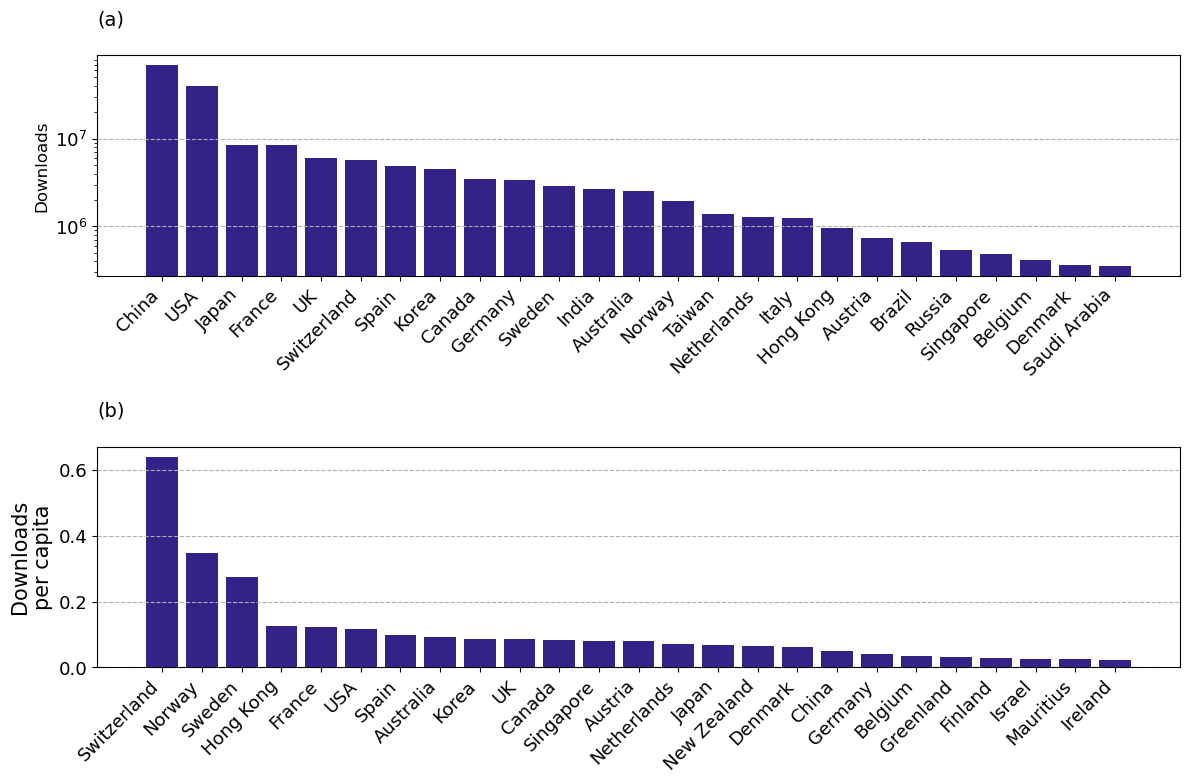

In [41]:
## plot the total and per capita download stats by country

# sort and keep only top X for plotting

fig, axs = plt.subplots(2, 1, figsize=(12, 8))

ax = axs[0]
ax.set_title('(a)', loc='left', fontsize=14)
df_sorted = df_cld.sort_values(by='num_downloads', ascending=False).head(25)
ax.bar(df_sorted['country'], df_sorted['num_downloads'], color=colors[0])
ax.set_yscale('log')
ax.set_ylabel('Downloads', fontsize='large')
labels = ax.get_xticklabels()
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.grid(axis='y', linestyle='--')


ax = axs[1]
ax.set_title('(b)', loc='left', fontsize=14)
df_sorted = df_cld.sort_values(by='downloads_per_capita', ascending=False).head(25)
ax.bar(df_sorted['country'], df_sorted['downloads_per_capita'], color=colors[0])
#ax.set_yscale('log')
ax.set_ylabel('Downloads\nper capita')
labels = ax.get_xticklabels()
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.grid(axis='y', linestyle='--')

plt.tight_layout()

plt.savefig('plots/Country_downloads_per_capita_bars.png', dpi=300, bbox_inches='tight')

plt.show()

In [42]:
#### set up for map plot

# Download Natural Earth shapefiles automatically via cartopy
shapename = 'admin_0_countries'
countries_shp = shapereader.natural_earth(resolution='110m',
                                          category='cultural', name=shapename)

country_shape_names = []
for country in shapereader.Reader(countries_shp).records():
    country_shape_names.append(country.attributes['NAME_LONG'])
#country_shape_names 

# some of these are corrected back following the mapping above, 
# but two mappings needed to align all 3 of shape file, ESGF data, and population stats
country_rename_dict_for_shapes = { 
    'USA':'United States',
    'UK':'United Kingdom',
    'Russia': 'Russian Federation',
    'Congo (Kinshasa)':'Democratic Republic of the Congo',
    'Korea':'Republic of Korea',
    'Laos':'Lao PDR',
    'Swaziland':'Kingdom of eSwatini',
    "Cote d'Ivoire":"Côte d'Ivoire",
    
}


df_cld_rn = df_cld.copy()
df_cld_rn['country'] = df_cld_rn['country'].replace(country_rename_dict_for_shapes)
df_cld_rn['downloads_per_1000'] = df_cld_rn['downloads_per_capita']*1000
df_cfd_map = df_cld_rn.set_index('country')['downloads_per_1000'].to_dict()


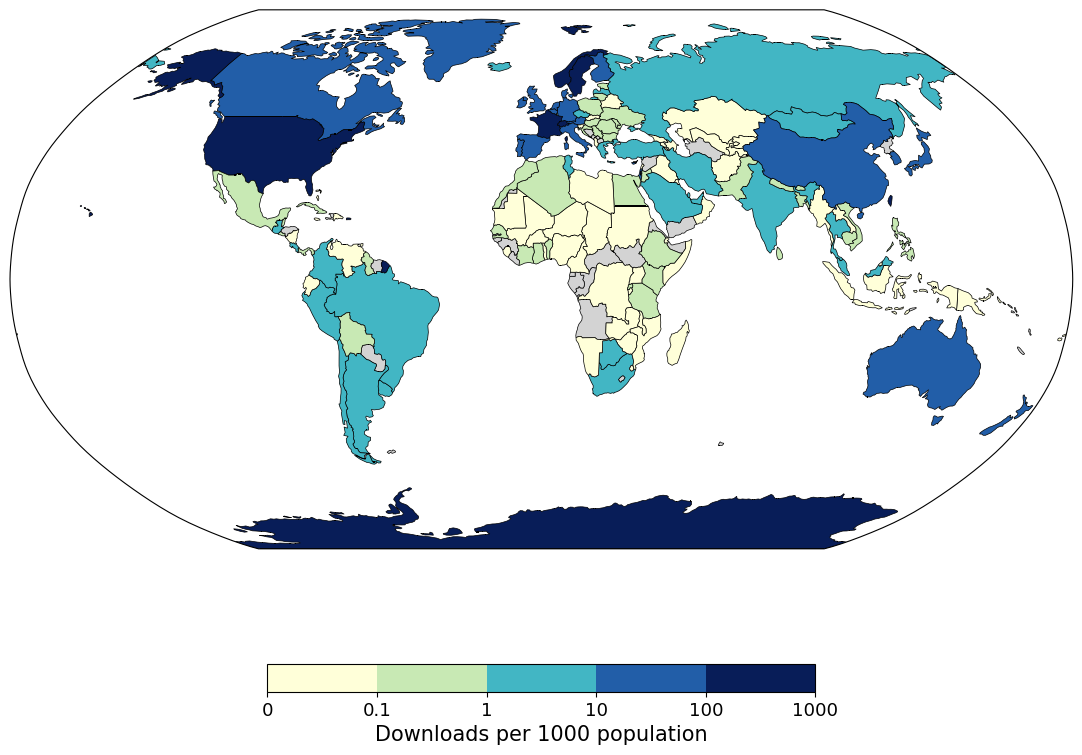

In [43]:


# Plot
fig = plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
#ax.coastlines()

boundaries = [0, 0.1, 1, 10, 100, 1000]
cmap = plt.cm.YlGnBu
#cmap = plt.cm.viridis
N_BINS = len(boundaries) - 1
norm = matplotlib.colors.BoundaryNorm(
    boundaries, 
    cmap.N
)

# Iterate through the country features in the shapefile
for country_feature in shapereader.Reader(countries_shp).records():
    # The 'NAME_LONG' attribute usually holds the country name in Natural Earth
    country_name = country_feature.attributes['NAME_LONG']
    
    # Check if the country name is in our data
    if country_name in df_cfd_map:
        value = df_cfd_map[country_name]
        
        # Determine the color based on the value
        facecolor = cmap(norm(value))
        
        # Plot the feature geometry
        ax.add_geometries(
            [country_feature.geometry],  # Geometry to plot
            ccrs.PlateCarree(),          # Projection of the geometry
            facecolor=facecolor,
            edgecolor='black',
            linewidth=0.5,
            zorder=1 # Ensure countries are plotted before coastlines if desired
        )
    else:
        #print(country_name)
        # Plot countries not in our data with a neutral color (e.g., light gray)
        ax.add_geometries(
            [country_feature.geometry],
            ccrs.PlateCarree(),
            facecolor='lightgray',
            edgecolor='black',
            linewidth=0.5,
            zorder=0
        )


sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', shrink=0.4)
cbar.set_label('Downloads per 1000 population')
cbar.set_ticklabels(boundaries)

plt.tight_layout()

plt.savefig('plots/Country_per_capita_downloads_map.png', dpi=300, bbox_inches='tight')
plt.show()

# Section 4 Other data providers

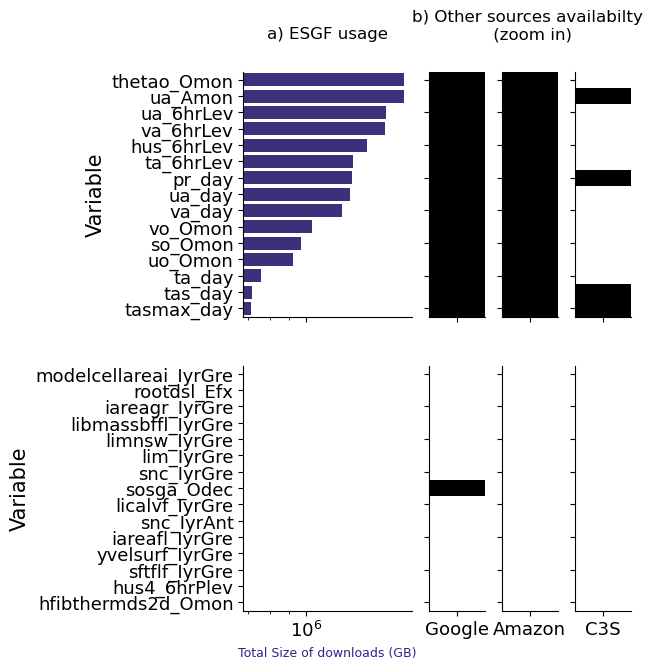

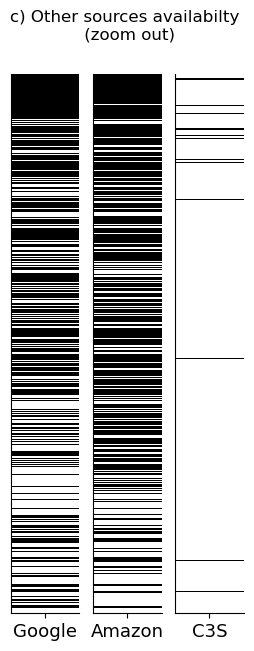

In [44]:
fig, axs = plt.subplots(2,4, figsize=(5,7), sharex='col', gridspec_kw={'width_ratios':[3,1,1,1],'hspace':0.2})
n=15
sns.barplot(x='total_size_GB', y='unique',data=df_gb[:n], ax=axs[0,0], color=colors[0])
sns.barplot(x='total_size_GB', y='unique',data=df_gb[-n:], ax=axs[1,0], color=colors[0])
axs[0,0].set_xscale('log')
axs[1,0].set_xscale('log')
axs[1,0].set_xlabel('Total Size of downloads (GB)', color=colors[0], fontsize=9)
axs[0,0].set_ylabel('Variable')
axs[1,0].set_ylabel('Variable')
#axs[0,0].set_xlim((0.9,1e7))
#axs[1,0].set_xlim((0.9,1e7))
sns.heatmap(df_gb[['google','unique']].set_index('unique')[:n], cmap='Greys', ax=axs[0,1], cbar=False,vmax=1,vmin=0)
sns.heatmap(df_gb[['google','unique']].set_index('unique')[-n:], cmap='Greys', ax=axs[1,1], cbar=False,vmax=1,vmin=0)
axs[0,1].set_ylabel('')
axs[1,1].set_ylabel('')
axs[0,1].set_yticklabels([])
axs[1,1].set_yticklabels([])

#axs[0,1].set_xlabel('google')
#axs[1,1].set_xlabel('amazon')
    
sns.heatmap(df_gb[['amazon','unique']].set_index('unique')[:n], cmap='Greys', ax=axs[0,2], cbar=False,vmax=1,vmin=0)
sns.heatmap(df_gb[['amazon','unique']].set_index('unique')[-n:], cmap='Greys', ax=axs[1,2], cbar=False,vmax=1,vmin=0)
axs[0,2].set_ylabel('')
axs[1,2].set_ylabel('')
axs[0,2].set_yticklabels([])
axs[1,2].set_yticklabels([]);



sns.heatmap(df_gb[['copernicus','unique']].set_index('unique')[:n], cmap='Greys', ax=axs[0,3], cbar=False,vmax=1,vmin=0)
sns.heatmap(df_gb[['copernicus','unique']].set_index('unique')[-n:], cmap='Greys', ax=axs[1,3], cbar=False,vmax=1,vmin=0)
axs[0,3].set_ylabel('')
axs[1,3].set_ylabel('')
axs[0,3].set_yticklabels([])
axs[1,3].set_yticklabels([]);

axs[0,0].set_title('a) ESGF usage')
axs[0,2].set_title('b) Other sources availabilty \n (zoom in)')
axs[1,1].set_xticklabels(['Google'])
axs[1,2].set_xticklabels(['Amazon'])
axs[1,3].set_xticklabels(['C3S'])
plt.subplots_adjust( hspace=0.05)
for ax in axs.ravel():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)


fig.savefig('plots/otherAB.pdf',format='pdf', bbox_inches='tight',transparent=False)



fig, axs = plt.subplots(1,3, figsize=(3,7))

sns.heatmap(df_gb[['google','unique']].set_index('unique'), cmap='Greys', cbar=False,vmax=1,vmin=0,ax=axs[0])
axs[0].set_yticks([])

sns.heatmap(df_gb[['amazon','unique']].set_index('unique'), cmap='Greys', cbar=False,vmax=1,vmin=0,ax=axs[1])
axs[1].set_yticks([])

sns.heatmap(df_gb[['copernicus','unique']].set_index('unique'), cmap='Greys', cbar=False,vmax=1,vmin=0,ax=axs[2])
axs[2].set_yticks([])
axs[1].set_title('c) Other sources availabilty \n (zoom out)', y=1.05)
axs[0].set_ylabel('')
axs[2].set_ylabel('')
axs[1].set_ylabel('')

axs[0].set_xticklabels(['Google'])
axs[1].set_xticklabels(['Amazon'])
axs[2].set_xticklabels(['C3S'])

for ax in axs.ravel():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)

fig.savefig('plots/otherC.pdf',format='pdf', bbox_inches='tight',transparent=False)

[Text(0.5, 0, 'C3S')]

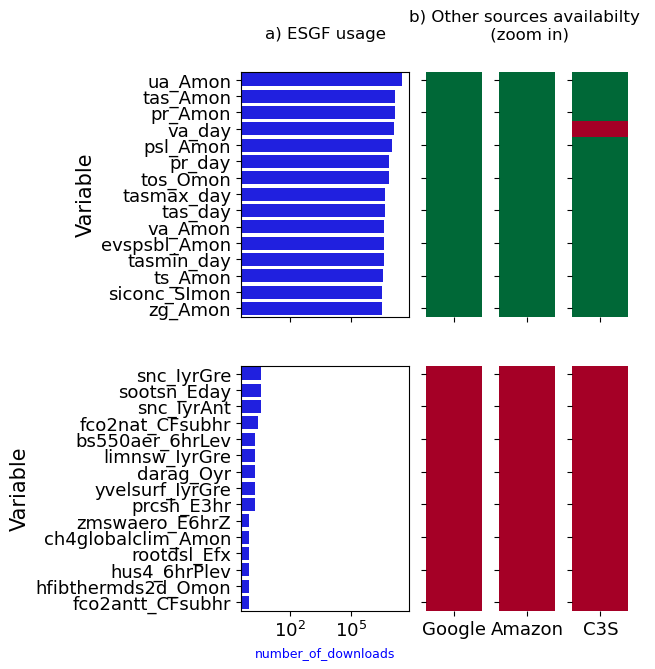

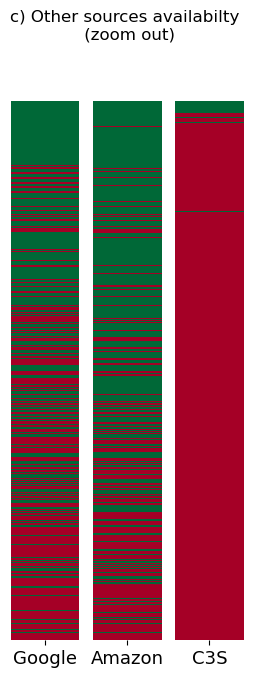

In [45]:
fig, axs = plt.subplots(2,4, figsize=(5,7), sharex='col', gridspec_kw={'width_ratios':[3,1,1,1],'hspace':0.2})
n=15
sns.barplot(x='number_of_downloads', y='unique',data=df_nd[:n], ax=axs[0,0], color='blue')
sns.barplot(x='number_of_downloads', y='unique',data=df_nd[-n:], ax=axs[1,0], color='blue')
axs[0,0].set_xscale('log')
axs[1,0].set_xscale('log')
axs[1,0].set_xlabel('number_of_downloads', color='blue', fontsize=9)
axs[0,0].set_ylabel('Variable')
axs[1,0].set_ylabel('Variable')
#axs[0,0].set_xlim((0.9,1e7))
#axs[1,0].set_xlim((0.9,1e7))
sns.heatmap(df_nd[['google','unique']].set_index('unique')[:n], cmap='RdYlGn', ax=axs[0,1], cbar=False,vmax=1,vmin=0)
sns.heatmap(df_nd[['google','unique']].set_index('unique')[-n:], cmap='RdYlGn', ax=axs[1,1], cbar=False,vmax=1,vmin=0)
axs[0,1].set_ylabel('')
axs[1,1].set_ylabel('')
axs[0,1].set_yticklabels([])
axs[1,1].set_yticklabels([])

#axs[0,1].set_xlabel('google')
#axs[1,1].set_xlabel('amazon')
    
sns.heatmap(df_nd[['amazon','unique']].set_index('unique')[:n], cmap='RdYlGn', ax=axs[0,2], cbar=False,vmax=1,vmin=0)
sns.heatmap(df_nd[['amazon','unique']].set_index('unique')[-n:], cmap='RdYlGn', ax=axs[1,2], cbar=False,vmax=1,vmin=0)
axs[0,2].set_ylabel('')
axs[1,2].set_ylabel('')
axs[0,2].set_yticklabels([])
axs[1,2].set_yticklabels([]);



sns.heatmap(df_nd[['copernicus','unique']].set_index('unique')[:n], cmap='RdYlGn', ax=axs[0,3], cbar=False,vmax=1,vmin=0)
sns.heatmap(df_nd[['copernicus','unique']].set_index('unique')[-n:], cmap='RdYlGn', ax=axs[1,3], cbar=False,vmax=1,vmin=0)
axs[0,3].set_ylabel('')
axs[1,3].set_ylabel('')
axs[0,3].set_yticklabels([])
axs[1,3].set_yticklabels([]);

axs[0,0].set_title('a) ESGF usage')
axs[0,2].set_title('b) Other sources availabilty \n (zoom in)')
axs[1,1].set_xticklabels(['Google'])
axs[1,2].set_xticklabels(['Amazon'])
axs[1,3].set_xticklabels(['C3S'])
plt.subplots_adjust( hspace=0.05)


fig.savefig('plots/otherAB.pdf',format='pdf', bbox_inches='tight',transparent=False)

fig, axs = plt.subplots(1,3, figsize=(3,7))

sns.heatmap(df_nd[['google','unique']].set_index('unique'), cmap='RdYlGn', cbar=False,vmax=1,vmin=0,ax=axs[0])
axs[0].set_yticks([])

sns.heatmap(df_nd[['amazon','unique']].set_index('unique'), cmap='RdYlGn', cbar=False,vmax=1,vmin=0,ax=axs[1])
axs[1].set_yticks([])

sns.heatmap(df_nd[['copernicus','unique']].set_index('unique'), cmap='RdYlGn', cbar=False,vmax=1,vmin=0,ax=axs[2])
axs[2].set_yticks([])
axs[1].set_title('c) Other sources availabilty \n (zoom out)')
axs[0].set_ylabel('')
axs[2].set_ylabel('')
axs[1].set_ylabel('')

axs[0].set_xticklabels(['Google'])
axs[1].set_xticklabels(['Amazon'])
axs[2].set_xticklabels(['C3S'])

#fig.savefig('plots/otherC.pdf',format='pdf', bbox_inches='tight',transparent=False)

# Section 4.1 AWS

# Section 4.2 C3S

## Load and Clean data

In [67]:
# mapping of names
m={
    'areacella': 'Grid-cell area for atmospheric grid variables',
    'areacello': 'Grid-cell area for ocean variables',
    'clt': 'Total cloud cover percentage',
    'deptho': 'Sea floor depth below geoid',
    'evspsbl': 'Evaporation including sublimation and transpiration',
    'hfls': 'Surface upward latent heat flux',
    'hfss': 'Surface upward sensible heat flux',
    'hur': 'Relative humidity',
    'hurs': 'Near-surface relative humidity',
    'hus': 'Specific humidity',
    'huss': 'Near-surface specific humidity',
    'mrro': 'Total runoff',
    'mrros': 'Surface runoff flux',
    'mrsofc': 'Capacity of soil to store water',
    'mrsos': 'Moisture in upper portion of soil column',
    'orog': 'Surface altitude',
    'pr': 'Precipitation',
    'prsn': 'Snowfall flux',
    'prw': 'Atmosphere water vapour content',
    'ps': 'Surface air pressure',
    'psl': 'Sea level pressure',
    'rlds': 'Surface downwelling longwave radiation',
    'rlus': 'Surface upwelling longwave radiation',
    'rlut': 'TOA outgoing longwave radiation',
    'rlutcs': 'TOA outgoing longwave flux assuming clear sky',
    'rsds': 'Surface downwelling shortwave radiation',
    'rsdt': 'TOA incident shortwave radiation',
    'rsus': 'Surface upwelling shortwave radiation',
    'rsut': 'TOA outgoing shortwave radiation',
    'rsutcs': 'TOA outgoing shortwave flux assuming clear sky',
    'sfcWind': 'Near-surface wind speed',
    'sfcWindmax': 'Daily maximum near-surface wind speed',
    'sftgif': 'Land ice area percentage',
    'sftlf': 'Percentage of the grid-cell occupied by land including lakes',
    'sftof': 'Sea area percentage',
    'siconc': 'Sea-ice area percentage on ocean grid',
    'simass': 'Sea-ice mass per area',
    'sitemptop': 'Surface temperature of sea-ice',
    'sithick': 'Sea-ice thickness',
    'snd': 'Snow depth',
    'snw': 'Surface snow amount',
    'sos': 'Sea surface salinity',
    'ta': 'Air temperature',
    'tas': 'Near-surface air temperature',
    'tasmax': 'Daily maximum near-surface air temperature',
    'tasmin': 'Daily minimum near-surface air temperature',
    'tauu': 'Surface downward eastward wind stress',
    'tauv': 'Surface downward northward wind stress',
    'tos': 'Sea surface temperature',
    'ts': 'Surface temperature',
    'ua': 'Eastward wind',
    'uas': 'Eastward near-surface wind',
    'va': 'Northward wind',
    'vas': 'Northward near-surface wind',
    'zg': 'Geopotential height',
    'zos': 'Sea surface height above geoid'
}
mapping_var = {v: k for k, v in m.items()}

In [68]:
#C3S var
df_var = pd.read_csv(f"data/C3S/new_cds_variables.csv")
df_var['clean_var']=[str(v).replace('near_surface', 'near-surface'
                               ).replace('grid_cell', 'grid-cell'
                                        ).replace('sea_ice', 'sea-ice'
                                                 ).replace('_', ' ').capitalize().replace('Toa','TOA') for v in df_var['variable']]
df_var['variable_code']= [mapping_var[v] if v in mapping_var else np.nan for v in df_var['clean_var'] ]
df_var['variable_code']= [v if v in m else vc for v,vc in zip(df_var['variable'], df_var['variable_code']) ]
df_var = df_var.groupby("variable_code", as_index=False).agg({
    "requests": "sum",
    "users": "sum",
})
df_var=df_var.sort_values('requests', ascending=False)
df_var=df_var[:15]

In [79]:
len(mapping_var)*2*9

1008

In [100]:
# C3S models
df_models = pd.read_csv(f"data/C3S/new_cds_models.csv")
df_models['model']=df_models['widget'].str.replace("_","-")
df_models['model']=df_models['model'].str.upper()
df_models = df_models.groupby("model", as_index=False).agg({
    "requests": "sum",
    "users": "sum",
    'widget':'first',
})
df_models=df_models.sort_values('requests', ascending=False)
df_models

,model,requests,users,widget
0,ACCESS-CM2,58474,1011,access_cm2
27,EC-EARTH3-VEG-LR,57706,476,ec_earth3_veg_lr
9,CESM2,40977,587,cesm2
46,MIROC6,32197,709,miroc6
19,CNRM-ESM2-1,29257,467,cnrm_esm2_1
31,GFDL-ESM4,28002,706,gfdl_esm4
50,MRI-ESM2-0,26830,602,mri_esm2_0
40,IPSL-CM6A-LR,25238,545,ipsl_cm6a_lr
49,MPI-ESM1-2-LR,24709,742,mpi_esm1_2_lr
16,CMCC-ESM2,23493,471,cmcc_esm2


In [106]:
# count availabilty, 1 for each var/freq/exp
models=[]
with urllib.request.urlopen(f"https://object-store.os-api.cci2.ecmwf.int/cci2-prod-catalogue/resources/projections-cmip6/constraints_b44322782a7049e9b395ee9694f53690463eb8b0880aa2b0e2f3243f7cb7eec6.json") as url:
    data = json.load(url)
    for x in data:
        models.extend(x['model'])
df_models['n_avail']=[models.count(m) for m in df_models['widget']]  
df_models['model+avail']= [f"{m} ({a})" for m,a in zip(df_models['model'],df_models['n_avail'])]
df_models.sort_values('requests')

,model,requests,users,widget,n_avail,model+avail
26,EC-EARTH3-VEG,104,41,ec_earth3_veg,43,EC-EARTH3-VEG (43)
47,MPI-ESM-1-2-HAM,125,20,mpi_esm_1_2_ham,15,MPI-ESM-1-2-HAM (15)
32,GISS-E2-1-G,188,62,giss_e2_1_g,44,GISS-E2-1-G (44)
20,E3SM-1-0,220,67,e3sm_1_0,31,E3SM-1-0 (31)
33,GISS-E2-1-H,237,68,giss_e2_1_h,32,GISS-E2-1-H (32)
22,E3SM-1-1-ECA,240,66,e3sm_1_1_eca,35,E3SM-1-1-ECA (35)
44,MIROC-ES2H,253,59,miroc_es2h,29,MIROC-ES2H (29)
21,E3SM-1-1,347,80,e3sm_1_1,51,E3SM-1-1 (51)
23,EC-EARTH3,649,87,ec_earth3,89,EC-EARTH3 (89)
52,NORCPM1,770,113,norcpm1,44,NORCPM1 (44)


## Figures

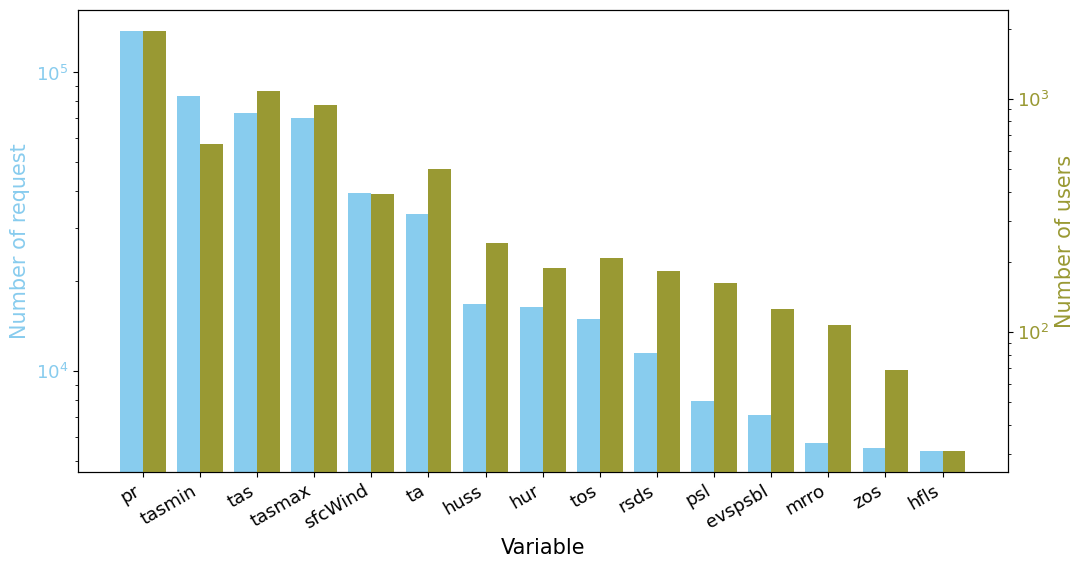

In [6]:
# Figure 5.2-1
fig, ax1, ax2=twinbarplot(
    list(df_var['requests']),
    list(df_var['users']),
    list(df_var['variable_code']),
    'Variable',
    ylabelL='Number of request',
    ylabelR='Number of users',
    colorL=colors[1],
    colorR=colors[4]
        
)
fig.savefig('plots/C3S_variable.pdf',format='pdf', bbox_inches='tight',transparent=False)

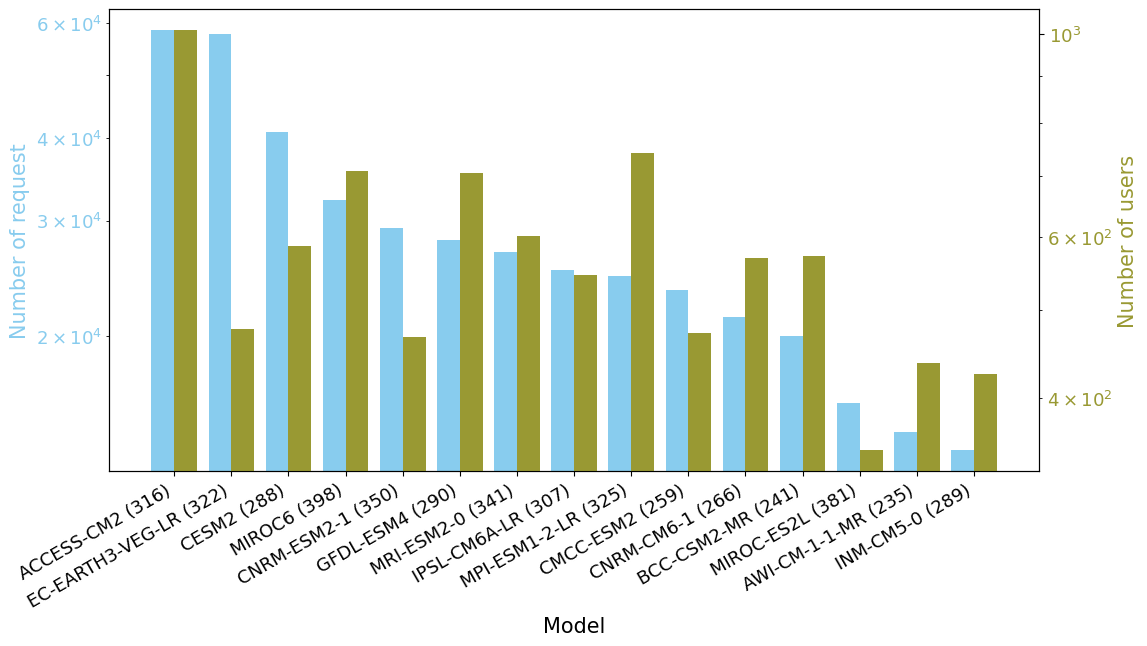

In [96]:
# Figure 5.2-2

fig, ax1, ax2=twinbarplot(
    list(df_models[:15]['requests']),
    list(df_models[:15]['users']),
    list(df_models[:15]['model+avail']),
    'Model',
    ylabelL='Number of request',
    ylabelR='Number of users',
    colorL=colors[1],
    colorR=colors[4]
        
)
#ax1.tick_params(axis='x', which='major', labelsize=6)
fig.savefig('plots/C3S_model.pdf',format='pdf', bbox_inches='tight',transparent=False)

In [97]:
len(df_models)

58

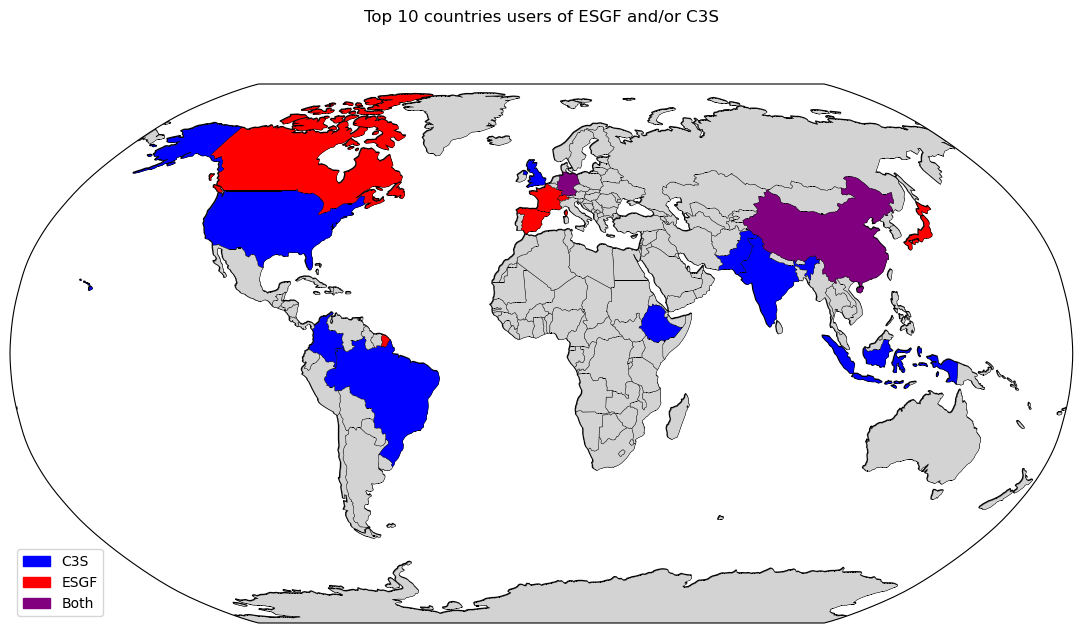

In [51]:
#Figure 5.2-3
df_user = pd.read_csv(f"data/C3S/new_cds_user_country.csv")
df_user=df_user.sort_values('dc(user_uid)', ascending=False)

df_cmcc = pd.read_csv(f"data/ESGF/CMIP6downloadsByCountry_13_01_2025.csv", encoding="latin-1")
df_cmcc=df_cmcc.sort_values('ï»¿num_downloads', ascending=False)

n=10
# Example lists
list_a = list(df_user.country[:n])
list_b = list(df_cmcc.country[:n])
list_b= [x.replace("United States of America",'United States',) for x in list_b]
# Download Natural Earth shapefiles automatically via cartopy
shapename = 'admin_0_countries'
countries_shp = shapereader.natural_earth(resolution='110m',
                                          category='cultural', name=shapename)

# Define colors
def get_color(name):
    if name in list_a and name in list_b:
        return "purple"   # both
    elif name in list_a:
        return "blue"     # only A
    elif name in list_b:
        return "red"    # only B
    else:
        return "lightgrey"  # other

# Plot
fig = plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()

for country in shapereader.Reader(countries_shp).records():
    geom = country.geometry
    name = country.attributes['NAME_LONG']  # country name field
    ax.add_geometries([geom], ccrs.PlateCarree(),
                      facecolor=get_color(name),
                      edgecolor="black", linewidth=0.3)

# Build legend
legend_patches = [
    mpatches.Patch(color="blue", label="C3S"),
    mpatches.Patch(color="red", label="ESGF"),
    mpatches.Patch(color="purple", label="Both"),

]

plt.legend(handles=legend_patches, loc="lower left", frameon=True)

plt.title(f"Top {n} countries users of ESGF and/or C3S")
plt.show()
fig.savefig('plots/C3S_map.pdf',format='pdf', bbox_inches='tight',transparent=False)

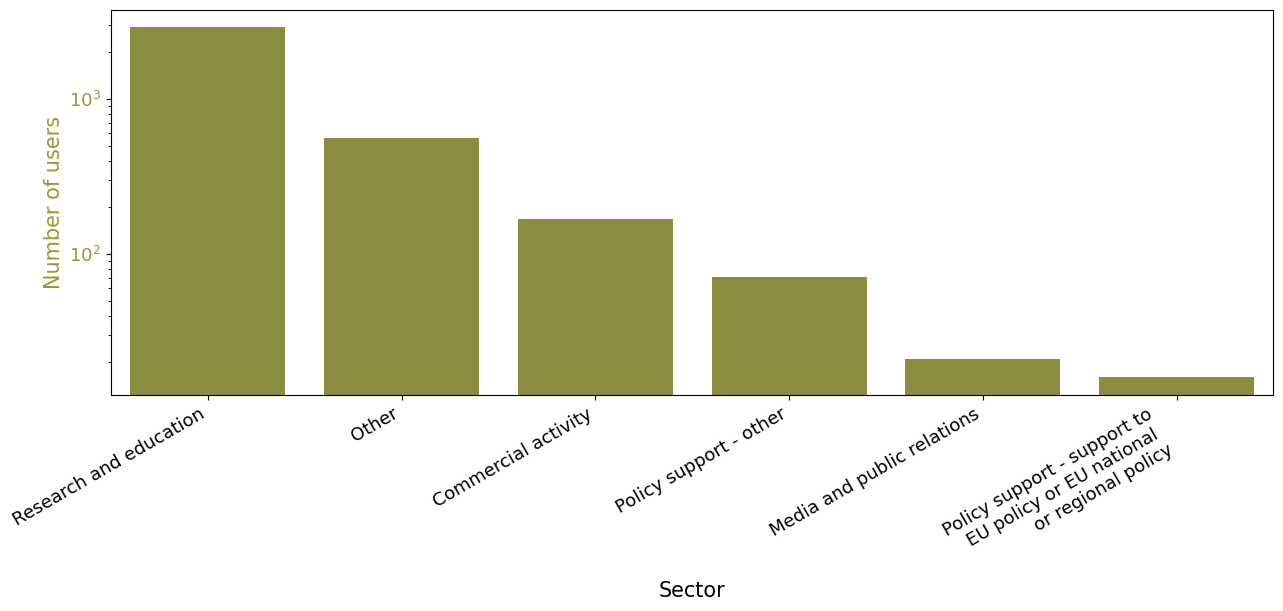

In [52]:
# Figure 5.2-4
df_sec = pd.read_csv(f"data/C3S/new_cds_user_sector.csv")
df_sec=df_sec.sort_values('dc(user_uid)', ascending=False)
df_sec['activity_sector']= df_sec['activity_sector'].str.replace('Policy support - support to EU policy or EU national or regional policy','Policy support - support to\n EU policy or EU national \nor regional policy')
n=15
plt.figure(figsize=(15,5))
ax=sns.barplot(y='dc(user_uid)', x='activity_sector',data=df_sec[:n], color=colors[4])
ax.set_yscale('log')
ax.set_ylabel('Number of users', color=colors[4])
ax.set_xlabel('Sector')
ax.tick_params(axis='y', labelcolor=colors[4], which='both')
plt.setp( ax.xaxis.get_majorticklabels(),rotation=30, ha='right');
fig.savefig('plots/C3S_sector.pdf',format='pdf', bbox_inches='tight',transparent=False)

# Section 6.1 Scientific Research

In [5]:
#get citation data and put it in a csv, no need to re-run it
path=f"data/FreshEyes/CMIP6_Data_References.csv"
df_ref=pd.read_csv(path, encoding="latin1")
if 'num_citation' not in df_ref:
    def get_datacite_citations(doi):
        url = f"https://api.datacite.org/dois/{doi}"
        try:
            r = requests.get(url)
            r.raise_for_status()
            data = r.json()
            return data["data"]["attributes"].get("citationCount", 0)
        except Exception as e:
            print(f"Error with {doi}: {e}")
            return None
    
    
    results = []
    for index, row in df.iterrows():
        doi=row['DOI'].replace('https://doi.org/','')
        results.append(get_datacite_citations(doi))
        
    df_ref['num_citation']=results
    df_ref.to_csv(path)
print(df_ref.num_citation.sum())
display(df_ref)

27456.0


,Unnamed: 0,DRS_ID,MIP_ERA,ACTIVITY_ID,INSTITUTION_ID,SOURCE_ID,EXPERIMENT_ID,DOI,Data Reference,License,License Uri,num_citation
0,0,CMIP6.AerChemMIP.AS-RCEC.TaiESM1,CMIP6,AerChemMIP,AS-RCEC,TaiESM1,NaN,https://doi.org/10.22033/ESGF/CMIP6.9682,"Tsai, I-Chun; Lee, Wei-Liang; Hsu, Huang-Hsiun...",CC BY 4.0,https://creativecommons.org/licenses/by/4.0/,3.0
1,1,CMIP6.AerChemMIP.AS-RCEC.TaiESM1.hist-piNTCF,CMIP6,AerChemMIP,AS-RCEC,TaiESM1,hist-piNTCF,https://doi.org/10.22033/ESGF/CMIP6.9744,"Tsai, I-Chun; Lee, Wei-Liang; Hsu, Huang-Hsiun...",CC BY 4.0,https://creativecommons.org/licenses/by/4.0/,0.0
2,2,CMIP6.AerChemMIP.AS-RCEC.TaiESM1.histSST,CMIP6,AerChemMIP,AS-RCEC,TaiESM1,histSST,https://doi.org/10.22033/ESGF/CMIP6.9747,"Tsai, I-Chun; Lee, Wei-Liang; Hsu, Huang-Hsiun...",CC BY 4.0,https://creativecommons.org/licenses/by/4.0/,0.0
3,3,CMIP6.AerChemMIP.AS-RCEC.TaiESM1.histSST-piNTCF,CMIP6,AerChemMIP,AS-RCEC,TaiESM1,histSST-piNTCF,https://doi.org/10.22033/ESGF/CMIP6.9752,"Tsai, I-Chun; Lee, Wei-Liang; Hsu, Huang-Hsiun...",CC BY 4.0,https://creativecommons.org/licenses/by/4.0/,0.0
4,4,CMIP6.AerChemMIP.AS-RCEC.TaiESM1.piClim-NTCF,CMIP6,AerChemMIP,AS-RCEC,TaiESM1,piClim-NTCF,https://doi.org/10.22033/ESGF/CMIP6.9790,"Tsai, I-Chun; Lee, Wei-Liang; Hsu, Huang-Hsiun...",CC BY 4.0,https://creativecommons.org/licenses/by/4.0/,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
3004,3004,input4MIPs.CMIP6.ScenarioMIP.UofMD.UofMD-landS...,input4MIPs,CMIP6,ScenarioMIP,UofMD,UofMD-landState-MAGPIE-ssp534-2-1-e,https://doi.org/10.22033/ESGF/input4MIPs.10922,"Hurtt, George; Chini, Louise; Sahajpal, Ritvik...",CC BY-SA 4.0,http://creativecommons.org/licenses/by-sa/4.0/,0.0
3005,3005,input4MIPs.CMIP6.ScenarioMIP.UofMD.UofMD-landS...,input4MIPs,CMIP6,ScenarioMIP,UofMD,UofMD-landState-MAGPIE-ssp534-2-1-f,https://doi.org/10.22033/ESGF/input4MIPs.9949,"Hurtt, George; Chini, Louise; Sahajpal, Ritvik...",CC BY-SA 4.0,http://creativecommons.org/licenses/by-sa/4.0/,0.0
3006,3006,input4MIPs.CMIP6.ScenarioMIP.UofMD.UofMD-landS...,input4MIPs,CMIP6,ScenarioMIP,UofMD,UofMD-landState-MAGPIE-ssp585-2-1-e,https://doi.org/10.22033/ESGF/input4MIPs.10923,"Hurtt, George; Chini, Louise; Sahajpal, Ritvik...",CC BY-SA 4.0,http://creativecommons.org/licenses/by-sa/4.0/,0.0
3007,3007,input4MIPs.CMIP6.ScenarioMIP.UofMD.UofMD-landS...,input4MIPs,CMIP6,ScenarioMIP,UofMD,UofMD-landState-MAGPIE-ssp585-2-1-f,https://doi.org/10.22033/ESGF/input4MIPs.1662,"Hurtt, George; Chini, Louise; Sahajpal, Ritvik...",CC BY-SA 4.0,http://creativecommons.org/licenses/by-sa/4.0/,2.0


In [6]:
#downloaded
df_source= pd.read_csv(f"data/ESGF/cmip6-sources_13_01_2025.csv")
display(df_source)
# published
df_model= pd.read_csv(f"data/ESGF/cmip6-models_13_01_2025.csv")
display(df_model)

,source_id_name,number_of_downloads,total_size_GB
0,EC-EARTH3,70435077,5091534.63
1,IPSL-CM6A-LR,2965261,3845623.97
2,MPI-ESM1-2-HR,6702396,3490023.05
3,CESM2,2925271,2611059.73
4,EC-EARTH3-VEG,26135094,2261190.15
...,...,...,...
140,PICLIM-BC,4,0.00
141,2BANDS,6,0.00
142,PICLIM-SO2,3,0.00
143,PICLIM-OC,3,0.00


,dimension,number_of_datasets,total_size_TB
0,4AOP-v1-5,12,0.00
1,ACCESS-CM2,49179,165.98
2,ACCESS-ESM1-5,323856,670.33
3,ACCESS-OM2,608,5.77
4,ACCESS-OM2-025,214,24.18
...,...,...,...
122,TaiESM1-TIMCOM,198,2.71
123,TaiESM1-TIMCOM2,169,2.28
124,UKESM1-0-LL,218607,743.47
125,UKESM1-1-LL,2445,6.44


In [7]:
# sum all the only source data
df_refsource=df_ref[df_ref['EXPERIMENT_ID'].isnull()].groupby('SOURCE_ID')['num_citation'].sum().reset_index()
df_refsource['SOURCE_ID_CAP']=pd.DataFrame(df_refsource['SOURCE_ID'].str.upper())
#align names
df_source=df_source.rename(columns={'source_id_name': 'SOURCE_ID_CAP', 'total_size_GB': 'total_size_GB_downloaded'})
df_model=df_model.rename(columns={'dimension': 'SOURCE_ID', 'total_size_TB':'total_size_TB uploaded'})
#merge
df_refsource= pd.merge(df_refsource,df_source, on='SOURCE_ID_CAP', )
df_refsource= pd.merge(df_model,df_refsource, on='SOURCE_ID')


In [8]:
# experiment,
df_exp= pd.read_csv(f"data/ESGF/cmip6-experiments_13_01_2025.csv")
# sum all the only source data
df_refexp=df_ref[~df_ref['EXPERIMENT_ID'].isnull()].groupby('EXPERIMENT_ID')['num_citation'].sum().reset_index()
df_refexp
#align names
df_exp=df_exp.rename(columns={'experiment_name': 'EXPERIMENT_ID', 'total_size_GB': 'total_size_GB_downloaded'})
#merge
df_refexp= pd.merge(df_refexp,df_exp, on='EXPERIMENT_ID', )

In [21]:
df_refsource

,SOURCE_ID,number_of_datasets,total_size_TB uploaded,num_citation,SOURCE_ID_CAP,number_of_downloads,total_size_GB_downloaded
0,4AOP-v1-5,12,0.00,0.0,4AOP-V1-5,304,0.11
1,ACCESS-CM2,49179,165.98,38.0,ACCESS-CM2,1078208,594693.43
2,ACCESS-ESM1-5,323856,670.33,61.0,ACCESS-ESM1-5,2865244,1259006.45
3,ACCESS-OM2,608,5.77,4.0,ACCESS-OM2,14494,3446.97
4,ACCESS-OM2-025,214,24.18,3.0,ACCESS-OM2-025,30275,20201.69
...,...,...,...,...,...,...,...
121,TaiESM1-TIMCOM,198,2.71,0.0,TAIESM1-TIMCOM,473,1080.37
122,TaiESM1-TIMCOM2,169,2.28,0.0,TAIESM1-TIMCOM2,531,1428.01
123,UKESM1-0-LL,218607,743.47,70.0,UKESM1-0-LL,1243827,965355.79
124,UKESM1-1-LL,2445,6.44,2.0,UKESM1-1-LL,4171,2470.39


In [26]:
# number of member by model
sizes=[]
members=[]

for source in df_refsource['SOURCE_ID']:
    with urllib.request.urlopen(f"https://esgf-data.dkrz.de/esg-search/search/"\
                                f"?limit=0&format=application%2Fsolr%2Bjson&mip_era=CMIP6&"\
                                "data_node=aims3.llnl.gov&data_node=data.meteo.unican.es&data_node=esg1.umr-cnrm.fr&data_node=esg-dn1.nsc.liu.se&data_node=esg-dn2.nsc.liu.se&data_node=esg-dn3.nsc.liu.se&data_node=esgf1.dkrz.de&data_node=esgf3.dkrz.de&data_node=esgf.bsc.es&data_node=esgf-data1.llnl.gov&data_node=esgf-data2.llnl.gov&data_node=esgf-data3.ceda.ac.uk&data_node=esgf-data3.llnl.gov&data_node=esgf-data4.lnll.gov&data_node=esgf-data7.ceda.ac.uk&data_node=esgf-data.ucar.edu&data_node=esgf.nci.org.au&data_node=esgf-node2.cmcc.it&data_node=vesg.ipsl.upmc.fr&"\
                                f"source_id={source}&facets=size,variant_label&distrib=true") as url:
        data = json.load(url)
        members.append(len(data['facet_counts']['facet_fields']['variant_label']))
df_refsource['nb_member']=members
df_refsource

,SOURCE_ID,number_of_datasets,total_size_TB uploaded,num_citation,SOURCE_ID_CAP,number_of_downloads,total_size_GB_downloaded,nb_member,upload_size_GB
0,4AOP-v1-5,12,0.00,0.0,4AOP-V1-5,304,0.11,6,0.002698
1,ACCESS-CM2,49179,165.98,38.0,ACCESS-CM2,1078208,594693.43,8,12525.982843
2,ACCESS-ESM1-5,323856,670.33,61.0,ACCESS-ESM1-5,2865244,1259006.45,60,21010.262148
3,ACCESS-OM2,608,5.77,4.0,ACCESS-OM2,14494,3446.97,0,0.000000
4,ACCESS-OM2-025,214,24.18,3.0,ACCESS-OM2-025,30275,20201.69,0,0.000000
...,...,...,...,...,...,...,...,...,...
121,TaiESM1-TIMCOM,198,2.71,0.0,TAIESM1-TIMCOM,473,1080.37,0,0.000000
122,TaiESM1-TIMCOM2,169,2.28,0.0,TAIESM1-TIMCOM2,531,1428.01,0,0.000000
123,UKESM1-0-LL,218607,743.47,70.0,UKESM1-0-LL,1243827,965355.79,50,79082.153013
124,UKESM1-1-LL,2445,6.44,2.0,UKESM1-1-LL,4171,2470.39,0,0.000000


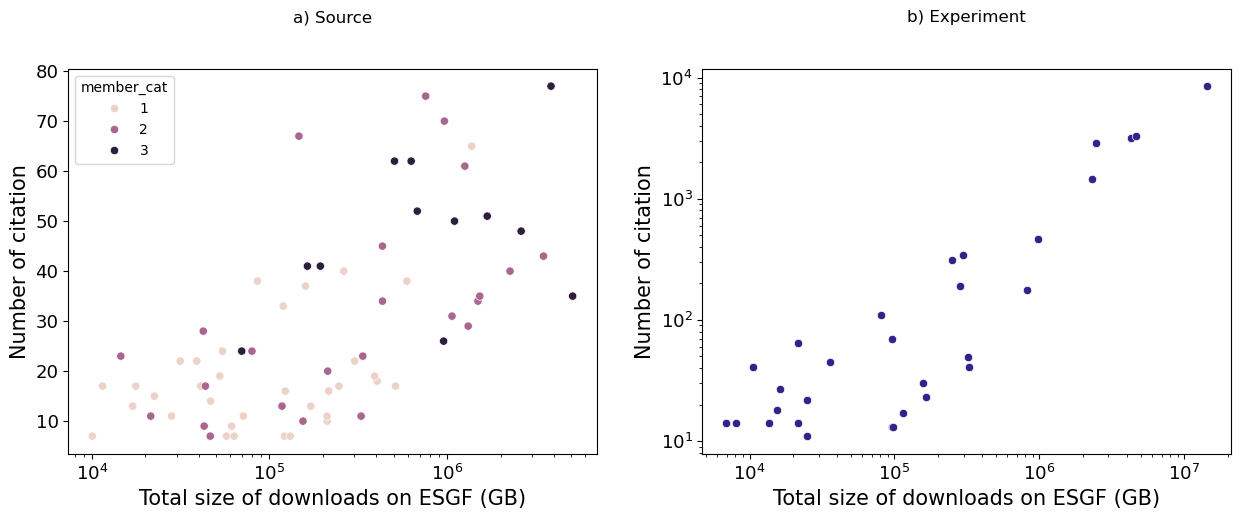

In [49]:
fig, axs= plt.subplots(1,2,figsize=(15,5))


g=sns.scatterplot(
    data=df_refsource[df_refsource['num_citation']>5], #color=colors[0],
    x="total_size_GB_downloaded", y="num_citation",
    hue='member_cat',
    #hue='nb_member',
    ax=axs[0]
)
g.set(xscale="log",xlabel="Total size of downloads on ESGF (GB)",ylabel="Number of citation", title='a) Source')

g = sns.scatterplot(
    data=df_refexp[df_refexp['num_citation']>10],
    x="total_size_GB_downloaded", y="num_citation",ax=axs[1],color=colors[0],
)
g.set(xscale="log",yscale='log',xlabel="Total size of downloads on ESGF (GB)",ylabel="Number of citation", title='b) Experiment')
fig.savefig('plots/citations.pdf',format='pdf', bbox_inches='tight',transparent=False)

In [58]:
df_refsource[df_refsource["SOURCE_ID"]=='EC-Earth3']

,SOURCE_ID,number_of_datasets,total_size_TB uploaded,num_citation,SOURCE_ID_CAP,number_of_downloads,total_size_GB_downloaded
40,EC-Earth3,551873,2294.36,35.00,EC-EARTH3,70435077,5091534.63
